# Part 1: product_recommendation_system.ipynb

This section was copied from the source notebook during merge.


---

# Project: Amazon Product Recommendation System

## Introduction

This project involves developing a recommendation system using Amazon's product reviews dataset, specifically focusing on electronic products. The dataset includes product ratings but excludes additional product information or reviews to maintain an unbiased model-building process.

### Context
The exponential growth of information in terms of volume, velocity, and variety has created significant challenges for consumers, who often face an overwhelming number of choices. Recommender systems provide an effective solution by suggesting relevant products to users while they browse online, enhancing engagement and supporting business goals.

E-commerce platforms like Amazon, Walmart, Target, and Etsy invest heavily in developing sophisticated recommendation models to deliver personalized suggestions. Amazon's recommendation system, known for its accuracy, leverages advanced algorithms to predict customers' preferences and offer tailored product recommendations. A key component of this system is the item-to-item collaborative filtering model, which efficiently handles massive datasets to deliver high-quality, real-time recommendations.

### Objective
The objective is to build a recommendation system to suggest products to Amazon customers based on their previous ratings. Utilizing a labeled dataset of Amazon product reviews, the goal is to extract meaningful insights and develop a model that enhances product recommendations for online consumers. The project will explore various approaches, including:

1. **Knowledge/Rank-Based Recommendation System**:  
   This model recommends products based on predefined rules or ranking criteria, such as popularity or average ratings. It does not consider individual user preferences but instead suggests items that are generally well-rated or popular among all users. This approach is particularly effective for addressing cold start problems by recommending popular items to new users, ensuring relevant suggestions from the start.
2. **User-User Collaborative Filtering**:  
   This model recommends products by identifying users with similar behavior patterns and suggesting items those users have liked or rated highly. The recommendation is based on the idea that users who have similar preferences will like similar items, focusing on user-to-user similarity to make predictions.
3. **Item-Item Collaborative Filtering**:  
   This model works similarly to user-user collaborative filtering but instead focuses on item-to-item similarity. It identifies items that have been rated similarly by the same users and recommends products that are similar to those the user has already interacted with, making it ideal for users with established preferences.
4. **Matrix Factorization-Based Collaborative Filtering**:  
   This model reduces the dimensionality of the user-item interaction matrix using techniques like Singular Value Decomposition (SVD). It captures latent factors that represent both user preferences and item characteristics, predicting missing ratings and making personalized recommendations based solely on user-item interaction data.
5. **Hybrid Recommendation System**:  
   This model combines multiple recommendation techniques, such as collaborative filtering, content-based filtering, and knowledge-based methods, to leverage the strengths of each and mitigate their weaknesses. By integrating different algorithms, the hybrid system aims to improve both the accuracy and relevance of the recommendations.

### Data Dictionary
The Amazon product reviews dataset contains the following attributes:
- **user_id**: A unique identifier for each user.
- **prod_id**: A unique identifier for each product.
- **rating**: The rating given to a product by a user.
- **timestamp**: The time when the rating was given by a given user.

### Performance Metrics
The following key performance metrics will be used to evaluate and guide the comparison and tuning of different recommendation approaches, ensuring the final model provides accurate, diverse, and relevant suggestions to users.

**Predictive Metrics**
- **Root Mean Squared Error (RMSE)**: Measures the difference between predicted and actual ratings, indicating how accurately the model estimates user preferences. Lower RMSE values signify better predictive performance.
- **Precision@K**: The fraction of recommended items that are relevant within the top K predictions. The value of K represents the number of recommendations provided to the user and can be adjusted based on specific needs. Higher precision indicates that the model is effectively recommending items users are likely to engage with.
- **Recall@K**: The fraction of relevant items that are recommended to the user within the top K predictions. Higher recall reflects the model's ability to capture a wider range of items users may find relevant.
- **F1 Score@K**: The harmonic mean of Precision@K and Recall@K. This metric is useful when both precision and recall are important, as it provides a balanced measure that considers both aspects.

**Ranking Metrics**
- **Mean Reciprocal Rank (MRR)**: Measures the ranking quality by averaging the reciprocal rank of the first relevant item in the recommended list. Higher MRR values suggest that relevant items are ranked earlier, enhancing user experience.
- **Mean Average Precision (MAP)**: Evaluates the average precision across all users, indicating how consistently the model ranks relevant items in its recommendations.
- **Hit Rate@K**: The proportion of cases where at least one relevant item is present in the top-K recommendations. A higher hit rate demonstrates the model's reliability in including relevant items.

---

## Importing Necessary Libraries and Data

This section sets up the environment by importing essential libraries for data manipulation, visualization, recommendation system modeling, and evaluation. It includes modules for handling datasets, performing Exploratory Data Analysis (EDA), and building the collaborative filtering models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r "/content/drive/MyDrive/ecommerce-recsys-finetuning" "/content/ecommerce-recsys-finetuning"
%cd /content/ecommerce-recsys-finetuning

!pip install -r requirements.txt

!pip install scikit-surprise

!ls -lh data/raw
!head -n 3 data/raw/amazon_product_ratings_part_1.csv

In [ ]:
# ----------------------------------------------------------------------
# Utility Libraries for Directory and File Handling
# ----------------------------------------------------------------------

# import copy  # For deep copying objects
import pickle  # For serializing and saving Python objects
from pathlib import Path  # For filesystem path handling
import sys  # For managing system paths
import time  # For tracking execution time
import warnings  # For suppressing warnings

# Start timer
start_time = time.time()

# Suppress warnings
warnings.filterwarnings("ignore")

# Add the parent directory to the system path to access custom modules
sys.path.append("../")


In [ ]:
# ----------------------------------------------------------------------
# Libraries for Data Manipulation, and Visualization
# ----------------------------------------------------------------------

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

%matplotlib inline

# Jupyter notebook display utilities
from IPython.display import Markdown, display

# ----------------------------------------------------------------------
# Surprise Library for Recommender Systems
# ----------------------------------------------------------------------

# Data loading, parsing and splitting
from surprise.dataset import Dataset
from surprise.reader import Reader # (user ; item ; rating structure)
from surprise.model_selection import train_test_split

# Similarity-based and matrix factorization-based algorithms
from surprise.prediction_algorithms import (
    SVD,
    KNNBaseline,
    KNNBasic,
    KNNWithMeans,
    KNNWithZScore,
    SVDpp,
)


In [ ]:
# ----------------------------------------------------------------------
# Import Modules for Recommendation Systems, EDA and Utilities
# ----------------------------------------------------------------------

# Import classes for recommendation systems
from src.cf_recommender import CFRecommendationSystem
from src.hybrid_recommender import HybridRecommendationSystem
from src.content_based_recommendation import content_based_filtering

# Import functions for model evaluation
from src.model_eval_functions import baseline_gridsearch, evaluate_model

# Import functions for exploratory data analysis and utilities
from src.eda_functions import (
    barplot,
    barplot_subplots,
    palette_color,
    plot_interaction_boxplot,
    plot_interaction_histplot,
)

from src.utils import (
    prepare_and_display_metrics,
    read_all_csv_files,
    select_interactions,
)


---

## Loading Data

This section covers loading the dataset from multiple CSV files into a pandas DataFrame, preparing it for subsequent analysis and model development.

In [ ]:
# Read the new canonical interaction dataset
# ---------------------------------------------------------
# This merged notebook now uses the replacement dataset stored outside notebooks:
#   ../data/input/interaction_train.csv
#   ../data/input/interaction_test.csv
#
# The original Amazon raw files in ../data/raw are kept for reference only.
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "input").exists() and (PROJECT_ROOT.parent / "data" / "input").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_INPUT_DIR = PROJECT_ROOT / "data" / "input"
INTERACTION_TRAIN_FILE_MAIN = DATA_INPUT_DIR / "interaction_train.csv"
INTERACTION_TEST_FILE_MAIN = DATA_INPUT_DIR / "interaction_test.csv"

for input_file in [INTERACTION_TRAIN_FILE_MAIN, INTERACTION_TEST_FILE_MAIN]:
    if not input_file.exists():
        raise FileNotFoundError(f"Input file not found: {input_file}")

main_usecols = ["UserId", "ProductId", "Rating"]
train_raw = pd.read_csv(INTERACTION_TRAIN_FILE_MAIN, usecols=main_usecols, low_memory=False)
test_raw = pd.read_csv(INTERACTION_TEST_FILE_MAIN, usecols=main_usecols, low_memory=False)
raw_data = pd.concat([train_raw, test_raw], ignore_index=True)

print(f"Loaded train rows: {len(train_raw):,}")
print(f"Loaded test rows: {len(test_raw):,}")
print(f"Combined rows: {len(raw_data):,}")
raw_data.head()


Loaded train rows: 16,147,657
Loaded test rows: 2,563,231
Combined rows: 18,710,888


,UserId,ProductId,Rating
0,AEZHVS6IY6A74INPB3ZZYN3IOWWQ,B010CE497I,1.0
1,AHT5TJY7FJABJ2MOXZ2U6PPWILUQ,B09KHSM7BB,5.0
2,AFTZLUUSUAGH4OLYEIR4J3EP4V6A,B0BW9MF3WP,5.0
3,AH3GDPOFCJGULI4VANJ5UV3LTPNQ,B00I80XBMS,5.0
4,AFOCJSQEIJRYW7QFCSC67WLI7AYA,B071VZGZML,5.0


In [ ]:
# Standardize column names for the existing recommendation model code
# ---------------------------------------------------------
# Downstream model sections expect: user_id, prod_id, rating.
required_columns = ["UserId", "ProductId", "Rating"]
missing_columns = [col for col in required_columns if col not in raw_data.columns]
if missing_columns:
    raise ValueError(f"raw_data is missing required columns: {missing_columns}")

df = raw_data.rename(
    columns={
        "UserId": "user_id",
        "ProductId": "prod_id",
        "Rating": "rating",
        "Timestamp": "timestamp",
    }
)

df = df[["user_id", "prod_id", "rating"]].copy()
df["user_id"] = df["user_id"].astype(str).str.strip()
df["prod_id"] = df["prod_id"].astype(str).str.strip()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["user_id", "prod_id", "rating"])
df = df[(df["user_id"].str.len() > 0) & (df["prod_id"].str.len() > 0)].copy()

print(f"Model-ready rows: {len(df):,}")
print(f"Users: {df['user_id'].nunique():,}")
print(f"Products: {df['prod_id'].nunique():,}")
df.shape


Model-ready rows: 18,710,888
Users: 9,715,075
Products: 1,473,883


(18710888, 3)

## Data Preprocessing

This section addresses the challenges of dataset sparsity and size, with 7.8 million observations, by applying a balanced filtering strategy that iteratively adjusts thresholds for user and product ratings to prevent data loss and ensure a stable dataset size.

In [ ]:
# Define initial thresholds
user_threshold = 25
product_threshold = 5

# Define maximum threshold increments for iterative filtering
max_user_threshold = 50
max_product_threshold = 10

# Set convergence flag and initial dataset size
converged = False
prev_size = df.shape[0]

In [ ]:
# Initial filtering with low thresholds
user_ratings_count = df["user_id"].value_counts()
df = df[
    df["user_id"].isin(user_ratings_count[user_ratings_count >= user_threshold].index)
]

product_ratings_count = df["prod_id"].value_counts()
df = df[
    df["prod_id"].isin(
        product_ratings_count[product_ratings_count >= product_threshold].index
    )
]

# Set initial values for convergence check
prev_size = df.shape[0]
converged = False

while not converged:
    # Increment thresholds gradually
    if user_threshold < max_user_threshold:
        user_threshold += 5  # Increase user threshold incrementally
    if product_threshold < max_product_threshold:
        product_threshold += 1  # Increase product threshold incrementally

    # Filter users with at least the current user threshold ratings
    user_ratings_count = df["user_id"].value_counts()
    df = df[
        df["user_id"].isin(
            user_ratings_count[user_ratings_count >= user_threshold].index
        )
    ]

    # Filter products with at least the current product threshold ratings
    product_ratings_count = df["prod_id"].value_counts()
    df = df[
        df["prod_id"].isin(
            product_ratings_count[product_ratings_count >= product_threshold].index
        )
    ]

    # Check the current size of the dataset
    current_size = df.shape[0]

    # Check for convergence: if the dataset size decreases significantly, stop iterating
    if abs(prev_size - current_size) > 10000:  # Adjust this value as needed
        converged = True
    else:
        prev_size = current_size

    # If thresholds have reached maximum but no significant change, break to avoid infinite loop
    if (
        user_threshold >= max_user_threshold
        and product_threshold >= max_product_threshold
    ):
        print("Reached maximum thresholds without significant change. Stopping.")
        break

# Final thresholds applied
print(f"user_threshold: {user_threshold}")
print(f"product_threshold: {product_threshold}")

user_threshold: 30
product_threshold: 6


In [ ]:
# Reset index of dataset
df.reset_index(drop=True, inplace=True)

## Data Overview

This section provides a high-level summary of the dataset, detailing its dimensions, data types, and an initial look at the first and last few rows, along with checks for duplicate records and counts of unique values to confirm data integrity. The processed and cleaned data is exported as a pickle file for efficient storage and future use.

### High-Level Data Information

In [ ]:
# Number of rows and columns
df.shape

(498525, 3)

In [ ]:
# First 5 rows
df.head()

,user_id,prod_id,rating
0,AHBWAVRW22FT4GAN2VTWYNAEQFHQ,B0B51HYMBF,4.0
1,AF6VN3TUVQLOPONM5GPIG26BMHIQ,B0B51HYMBF,5.0
2,AHBXTSYI3ZKDKTL7IRBFGNSNR5YQ,B0B6WV7Z9V,4.0
3,AF6VN3TUVQLOPONM5GPIG26BMHIQ,B07C4LXP2P,3.0
4,AE3C6IBBFZDZQDZHSFJFBRJFKS2A,B0BS9NTRJ5,5.0


In [ ]:
# Last 5 rows
df.tail()

,user_id,prod_id,rating
498520,AH4A5WZPYTBD2DRIKIFKTMPLQ3CQ,B0BMT5ZY4V,5.0
498521,AH4A5WZPYTBD2DRIKIFKTMPLQ3CQ,B08NHLJP9N,5.0
498522,AH4A5WZPYTBD2DRIKIFKTMPLQ3CQ,B0BZPDZP6G,5.0
498523,AE5RJ7NLEORQE5KIRVYEP7HLSHQA,B09ZPXPZL6,5.0
498524,AE5RJ7NLEORQE5KIRVYEP7HLSHQA,B0BRQC9LQT,5.0


In [ ]:
# Summary of DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 498525 entries, 0 to 498524
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  498525 non-null  str    
 1   prod_id  498525 non-null  str    
 2   rating   498525 non-null  float64
dtypes: float64(1), str(2)
memory usage: 29.6 MB


### Unique and Duplicate Values

In [ ]:
# Number of duplicate rows
dvalues = df.duplicated().sum()

# Convert into DataFrame
duplicate_df = pd.DataFrame({"metric": ["duplicate_rows"], "count": [dvalues]})

# Display DataFrame
duplicate_df

,metric,count
0,duplicate_rows,8483


In [ ]:
# Number of unique values per feature
nuniq = df.nunique().reset_index()

# Rename column names
nuniq.columns = ["feature", "unique values"]

# Display DataFrame
nuniq

,feature,unique values
0,user_id,5806
1,prod_id,37187
2,rating,5


**Observations**:
- **Dimensions**: The dataset contains **78,798 rows** and **3 columns**.
- **Data Types**: Includes categorical (user and product IDs) and numerical (ratings) features.
- **Data Integrity**: No duplicate records or missing values, ensuring a clean dataset for modeling.
- **Unique Values**: The dataset contains **1,992 unique users** and **5,402 unique products**. The ratings are on a **5-point scale**.
- **Data Sparsity**: Out of **10,760,784 possible user-product interactions**, only **78,798 ratings** are recorded, reflecting typical sparsity in recommendation systems.
- **Additional Insights**: Further details and analyses are presented in subsequent sections.

### Export of Processed Data

In [ ]:
# Define the export path and filename for the processed and cleaned dataset
processed_data_filename = "../data/processed/processed_data.pkl"

# Export the dataset
with open(processed_data_filename, "wb") as f:
    pickle.dump(df, f)

# Print status log
print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Processed data exported successfully to '{processed_data_filename}'")

Dimensions: 498525 rows, 3 columns
Processed data exported successfully to '../data/processed/processed_data.pkl'


## Exploratory Data Analysis

This section provides an exploratory data analysis (EDA) of the dataset, examining the distribution of user and product interactions, ratings, and the overall structure, highlighting key trends such as the dominance of high ratings, the presence of outliers, and the skewed distribution of interactions.

### Statistical Analysis of DataFrame

In [ ]:
# Select categorical and numerical columns
cat_cols = list(df.select_dtypes(include=["object"]).columns)
num_cols = list(df.select_dtypes(include=[np.number]).columns)

#### Analysis of Numerical Data

In [ ]:
# Statistical summary of numerical data
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rating,498525.0,4.41,0.91,1.0,4.0,5.0,5.0,5.0


**Observations**:
- **Ratings Distribution**: The dataset consists of **78,798 unique ratings** with a **mean of 4.28** and a **median of 5.0**, indicating a strong skew towards higher values. Most ratings are **4.0 or higher**, with many users giving the maximum rating of **5.0**, reflecting a positive feedback trend.

#### Analysis of Categorical Data

In [ ]:
# Statistical summary of categorical data
df[cat_cols].describe().T

,count,unique,top,freq
user_id,498525,5806,AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1,1894
prod_id,498525,37187,B08NHLJP9N,645


**Observations**:
- **User Engagement**: The dataset includes **1,992 unique users**, with varying levels of engagement. The most active user has rated **283 products**, suggesting significant interaction from a small subset of users.
- **Product Popularity**: There are **5,402 unique products** in the dataset. The most frequently rated product has received **276 ratings**, highlighting the uneven distribution of interactions across items. 

### Univariate Analysis of Numerical Columns
For analysis purposes, the 'rating' column, consisting of discrete numbers from 1 to 5, will be treated as a categorical variable. This approach allows us to effectively observe its distribution and patterns.

#### Column | rating

Rating Distribution
------------------------------
 rating  percentage
    1.0        2.00
    2.0        2.80
    3.0        8.90
    4.0       24.86
    5.0       61.44
------------------------------


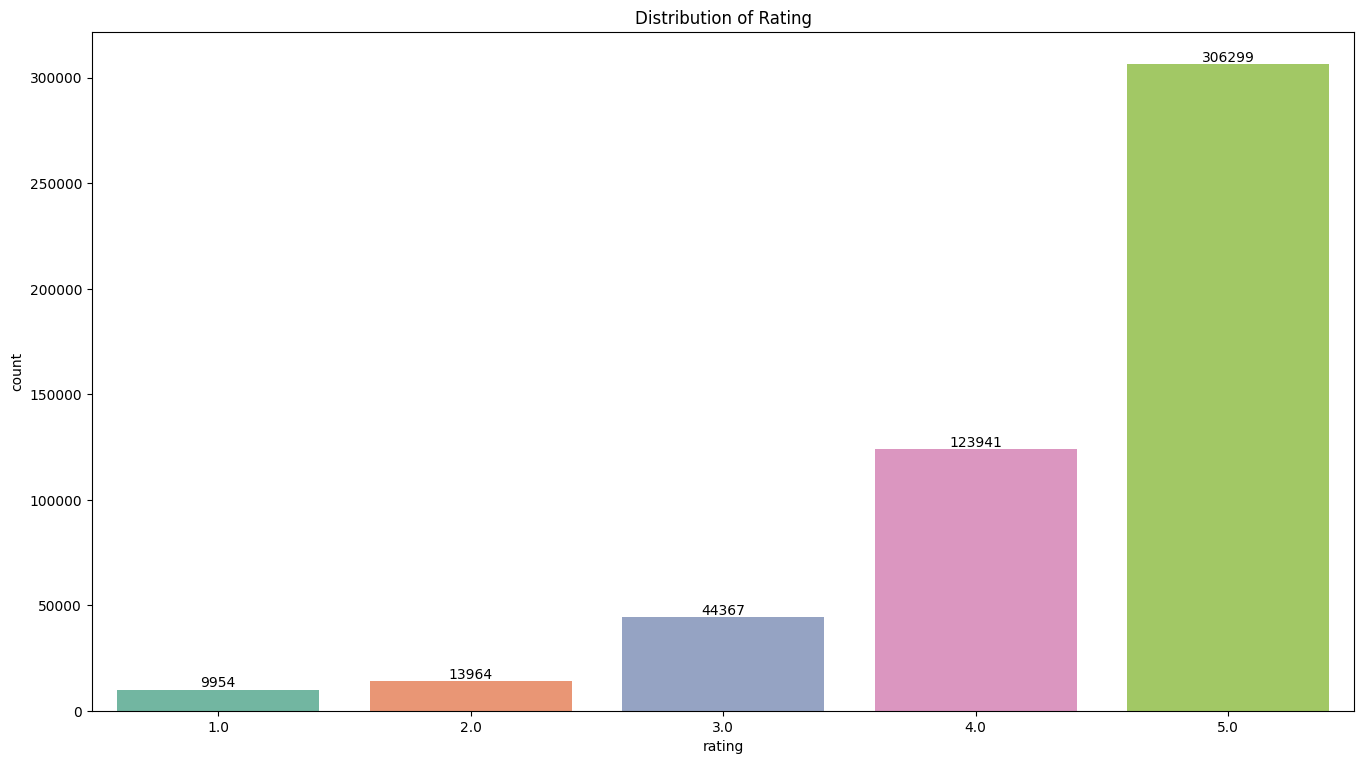

Mean: 4.41, Median: 5.0


In [ ]:
# Visualizing the distribution of the feature 'rating' and relative percentage annotations
barplot(df, "rating", perc=False)

**Observations**:
- **Dominance of High Ratings**: A significant **82.87%** of all ratings are either **5.0** (**54.24%**) or **4.0** (**28.63%**), while only **6.67%** are **1.0 or 2.0**. This **left-skewed distribution** indicates a strong user bias towards positive feedback, complicating model generalization.

### Univariate Analysis of Categorical Columns

#### Column | user_id, prod_id

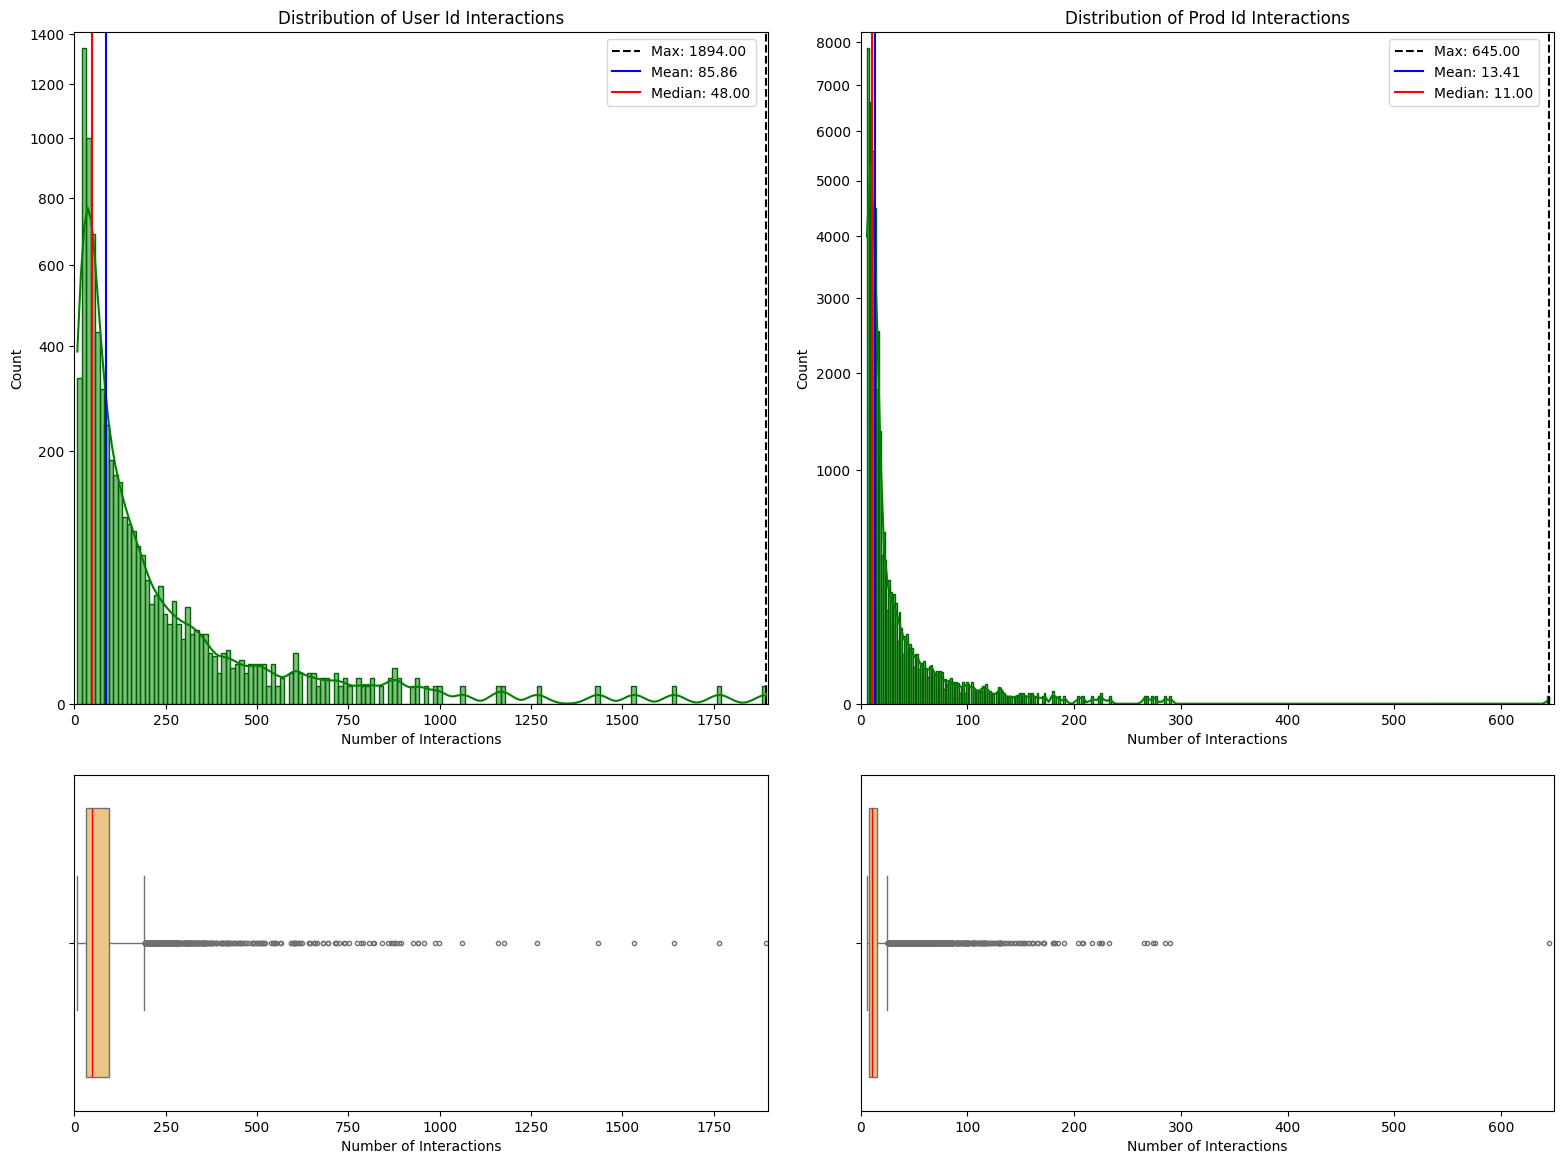

In [ ]:
# Note: Histplot y-axis is scaled by square root

# Create a combined figure with GridSpec
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, height_ratios=[2, 1])

# Plotting user-product interactions distribution (histplot)
ax0 = fig.add_subplot(gs[0, 0])
plot_interaction_histplot(df, "user_id", "prod_id", ax0)

# Plotting product-user interactions distribution (histplot)
ax1 = fig.add_subplot(gs[0, 1])
plot_interaction_histplot(df, "prod_id", "user_id", ax1)

# Plotting user-product interactions distribution (boxplot)
ax2 = fig.add_subplot(gs[1, 0])
plot_interaction_boxplot(df, "user_id", "prod_id", ax2)

# Plotting product-user interactions distribution (boxplot)
ax3 = fig.add_subplot(gs[1, 1])
plot_interaction_boxplot(df, "prod_id", "user_id", ax3)

# Synchronize x-axis limits for boxplots
ax2.set_xlim(ax0.get_xlim()[0], ax0.get_xlim()[1])
ax3.set_xlim(ax0.get_xlim()[0], ax1.get_xlim()[1])

plt.tight_layout(pad=2.0)
plt.show()

**Observations**:
- **Interaction Distribution**: Both user-product and product-user interactions are **right-skewed**, with **most users having 10 to 50 interactions** and **most products** interacting with **1 to 10 users**, indicating limited engagement.
- **Outlier Influence**: A small subset of users and products dominate interactions, with the maximum interactions reaching **283** for a user and **276** for a product. These outliers significantly exceed the average, emphasizing the uneven distribution in the dataset.


#### Column | user_id

Top 10 Entries
------------------------------
                       user_id  count
AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1   1894
  AG73BVBKUOH22USSFJA5ZWL7AKXA   1766
  AH2DN3Q2OKAW7JAFRIYPHOUOM2ZQ   1642
AEMP3A7IKW37CMWFXNKXWW6HGJHA_1   1533
  AFXF3EGQTQDXMRLDWFU7UBFQZB7Q   1433
  AFF6DS6NOWRIF2AROFASUVVOPYLA   1267
  AEZP6Z2C5AVQDZAJECQYZWQRNG3Q   1177
  AF4UB2PGVLHK45WF7I6OED36OQDA   1161
  AGYVC7KVHP2AWM7BDCEYNHFA6F3Q   1062
  AHY2TURQPNIDXZGH2CMQLZ343YMQ    999
------------------------------


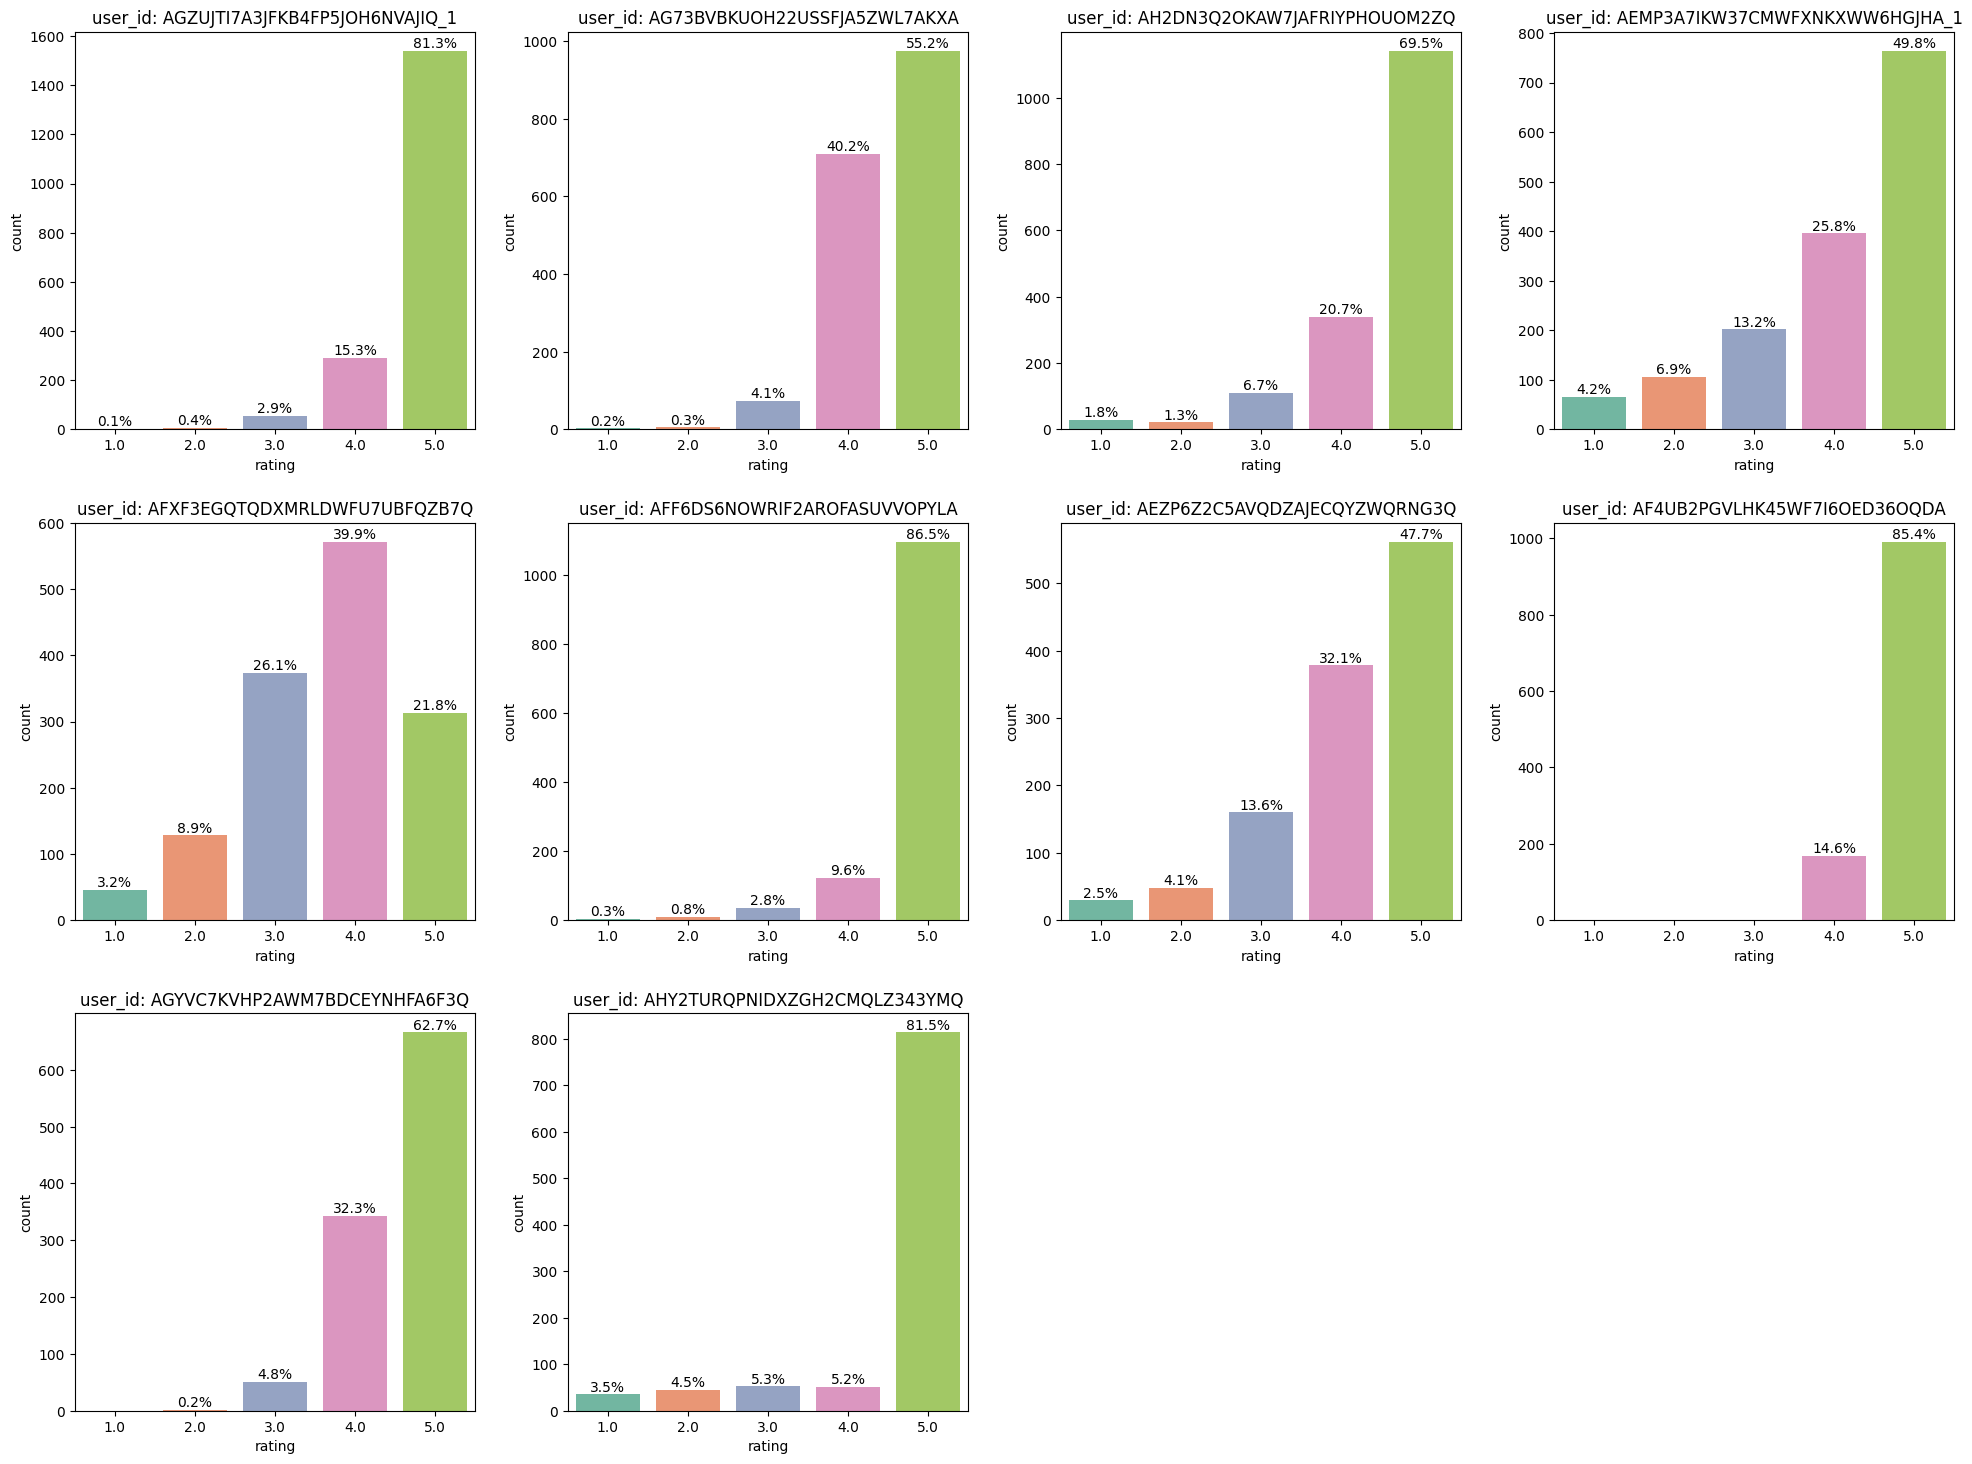

In [ ]:
# Visualizing the rating distribution for the top 10 users based on the total number of ratings
features = ["user_id", "rating"]
barplot_subplots(df, features, perc=True)

**Observations**:
- **Top User Engagement**: The most active user, 'ADLVFFE4VBT8', has **283 interactions**, with other top users engaging in **175 to 212 interactions**, indicating significant activity from a small user subset.
- **Positive Rating Bias**: Top users show a strong preference for **5-star ratings**, with percentages ranging from **46.6% to 78.6%**, while **1-star and 2-star ratings** remain rare (averaging **1% to 2%**). This suggests generally positive experiences or a reluctance to give low ratings.
- **Varied Rating Behavior**: While most top users favor **5-star ratings**, some, like 'A1ODOGXEYECQQ8', 'A22CW0ZHY3NJH8', and 'AGVWTYW0ULXHT', also give significant **3-star** and **4-star** ratings, indicating more nuanced satisfaction levels.

#### Column | prod_id

Top 10 Entries
------------------------------
   prod_id  count
B08NHLJP9N    645
B0BSZDMYZJ    290
B0B7JNYKQ2    285
B0B84KS8CX    276
B09ZKMD1VS    274
B08D8BL3X8    268
B0B6QVGZ4X    266
B09BZPYDV2    233
B0BZVVJXTF    226
B0C4HD8GDN    225
------------------------------


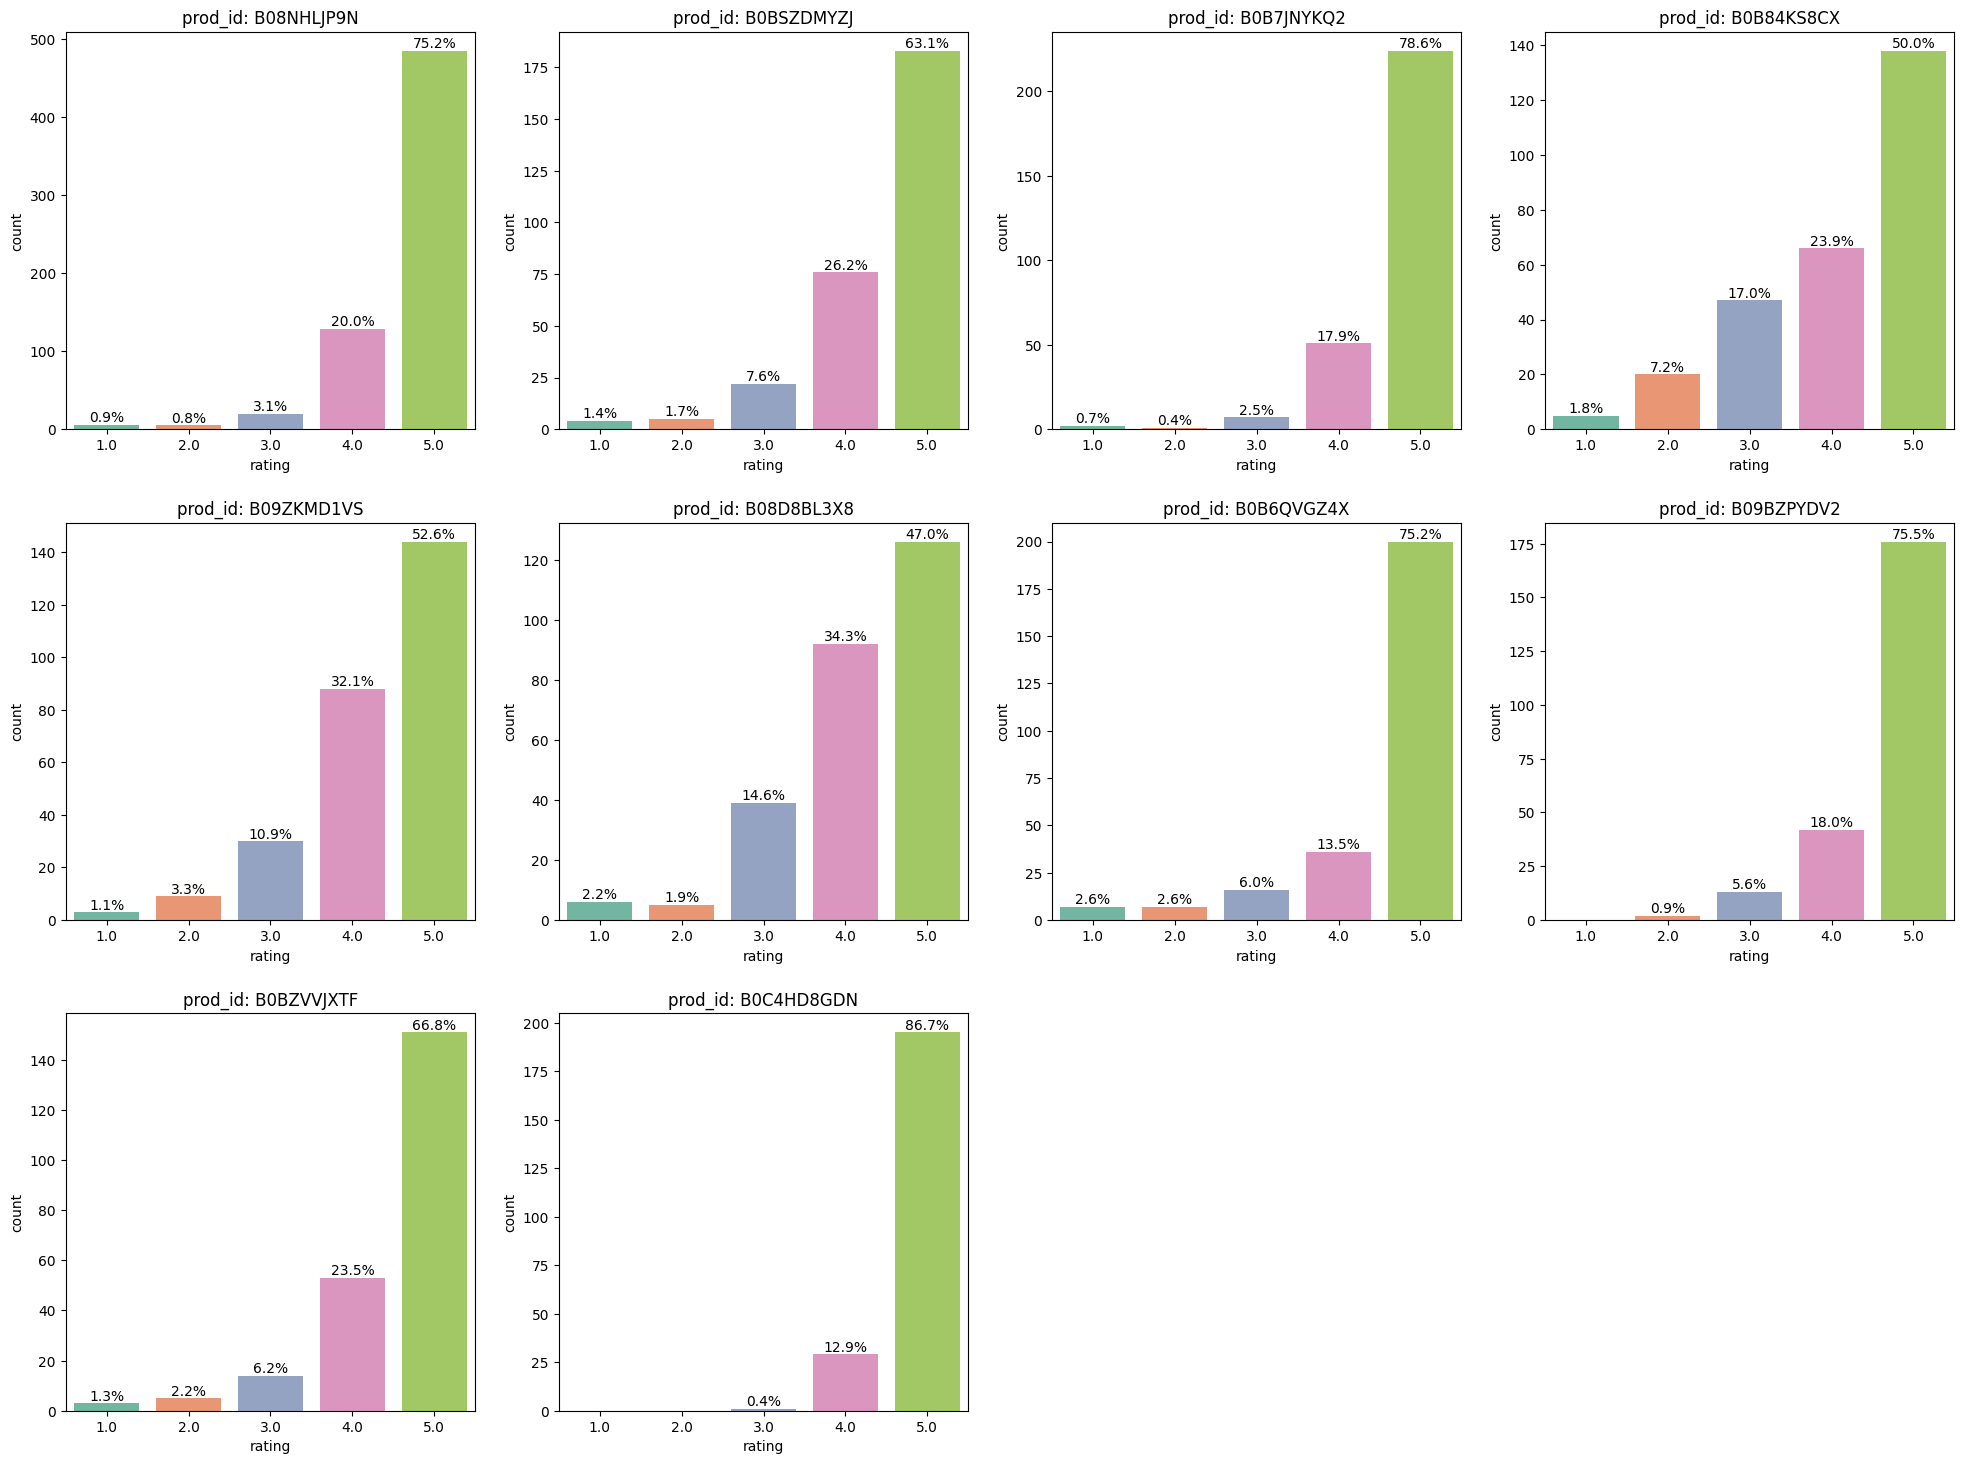

In [ ]:
# Visualizing the rating distribution for the top 10 products based on the total number of ratings
features = ["prod_id", "rating"]
barplot_subplots(df, features, perc=True)

**Observations**:
- **Top Products by Interaction**: The most frequently rated product, 'B0088CJT4U', has received **276 ratings**, while other products in the top 10 range from **236 to 148 ratings**, indicating significant engagement with a small subset of products.
- **Positive Rating Bias**: The top products display a strong preference for **5-star ratings**, with percentages spanning **44.2% to 88.6%** while **1-star and 2-star ratings** remain rare (averaging **1% to 2%**). This suggests generally positive experiences or a reluctance to leave poor ratings.
- **Varied Rating Behavior**: While **5-star ratings** dominate, products like 'B0088CJT4U', 'B008DWCRQW', and 'B002R5AM7C' exhibit a more diverse distribution, with significant portions of **3-star** and **4-star ratings**. This points to a more nuanced range of customer satisfaction levels for these items.

## Model Preparation and Setup

This section outlines the model preparation and setup, including loading the dataset into the format required by the `surprise` library, and setting global key variables for model evaluation.

### Data Preprocessing

In [ ]:
# Instantiate Reader scale with expected rating scale
reader = Reader(rating_scale=(0, 5))

# Load the rating dataset
data = Dataset.load_from_df(df[["user_id", "prod_id", "rating"]], reader=reader)

# Split the data into train and test datasets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Randomly select user IDs and retrieve their interacted and non-interacted products
user_interactions, user_non_interactions = select_interactions(
    trainset, num_users=2, num_products=4
)

**User Interactions**

{'AFAREB56ZQ27ZT5VLAWUED3KNRWA': [('B0B3DB5HTC', 5.0),
  ('B0B6QVGZ4X', 5.0),
  ('B0B7P2H6V4', 5.0),
  ('B0B6QVGZ4X', 5.0)],
 'AHCUM53LBD5BHNFJGMZHSG2GDZGQ': [('B09H8BY27C', 4.0),
  ('B09BXRMGXR', 5.0),
  ('B09MN6D2FC', 5.0),
  ('B0BP6P94T4', 3.0)]}

**User Non-Interactions**

{'AFAREB56ZQ27ZT5VLAWUED3KNRWA': ['B088QMG6P7',
  'B0B7L8N5L2',
  'B0B9L55WTG',
  'B09GSJ8BJ3'],
 'AHCUM53LBD5BHNFJGMZHSG2GDZGQ': ['B0BRKH7CZJ',
  'B08QYW2FJ2',
  'B0B4M3W3XF',
  'B0BVTC11SV']}

### Initialization of Key Parameters for Model Evaluation

In [ ]:
# Top-K recommendations for evaluation (Precision@K, Recall@K, etc.)
k = 10

# Rating threshold for recommendation relevance
threshold = 4.5  # Increased due to hugh volume of high ratings

# Cross validation iterator
cviter = 5

## Model 1: Rank-Based Recommendation System

This section now uses the **Popularity Model C** rank-based logic from the popularity notebook instead of the original simple Bayesian-only rank model.

The model builds product-level popularity features from the canonical training interactions and ranks products with:

- interaction popularity: views + carts + purchases
- recency decay
- Bayesian average rating

It keeps the same `model_rank` object name so the existing evaluation, recommendation, and hybrid sections can continue to run.

$$	ext{Score C} = w_p 	imes 	ext{PopularityDecayNorm} + w_b 	imes 	ext{BayesianNorm}$$

where:

- `PopularityDecayNorm` is the normalized popularity score after time decay.
- `BayesianNorm` is the normalized Bayesian average rating.
- `w_p` and `w_b` are the popularity and Bayesian weights.

For compatibility with the existing evaluation and hybrid model, `Score C` is scaled back to a 1-5 rating-like score.

### Baseline Model

In [ ]:
# Popularity Model C adapter for the existing Rank-Based / Hybrid pipeline
# ----------------------------------------------------------------------
# This replaces the previous simple Bayesian rank-based logic.
# It uses the rank-based popularity formula from the popularity notebook, while
# preserving the model_rank API expected by evaluation and HybridRecommendationSystem.

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from src.model_eval_functions import evaluate_model
from src.utils import display_eval_metrics


class PopularityRankRecommendationSystem:
    """Rank-based recommender using Popularity Model C from popularity.ipynb."""

    def __init__(
        self,
        interaction_train_file=None,
        popularity_train_file=None,
        chunksize=100_000,
        w_view=1.0,
        w_cart=3.0,
        w_purchase=5.0,
        decay_lambda=0.01,
        popularity_weight=0.5,
        bayesian_weight=0.5,
    ):
        project_root = Path.cwd()
        if not (project_root / "data" / "input").exists() and (project_root.parent / "data" / "input").exists():
            project_root = project_root.parent

        self.project_root = project_root
        self.interaction_train_file = Path(interaction_train_file or project_root / "data" / "input" / "interaction_train.csv")
        self.popularity_train_file = Path(popularity_train_file or project_root / "data" / "interim" / "popularity_train_dataset.csv")
        self.chunksize = chunksize
        self.w_view = w_view
        self.w_cart = w_cart
        self.w_purchase = w_purchase
        self.decay_lambda = decay_lambda
        self.popularity_weight = popularity_weight
        self.bayesian_weight = bayesian_weight

        self.algo_name = "Popularity-C"
        self.key_column = "popularity_rank_rating"
        self.scores = None

    @staticmethod
    def _safe_minmax(series):
        s = pd.to_numeric(series, errors="coerce").fillna(0)
        min_v = s.min()
        max_v = s.max()
        if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - min_v) / (max_v - min_v)

    def _build_popularity_train_dataset(self):
        if not self.interaction_train_file.exists():
            raise FileNotFoundError(f"Input file not found: {self.interaction_train_file}")

        self.popularity_train_file.parent.mkdir(parents=True, exist_ok=True)
        product_stats = {}
        total_rows = 0

        usecols = ["ProductId", "Rating", "Timestamp", "Date", "VerifiedPurchase"]

        for chunk_index, chunk in enumerate(
            pd.read_csv(
                self.interaction_train_file,
                usecols=lambda col: col in usecols,
                chunksize=self.chunksize,
                low_memory=False,
            ),
            start=1,
        ):
            chunk.columns = chunk.columns.str.strip()
            missing = [col for col in ["ProductId", "Rating"] if col not in chunk.columns]
            if missing:
                raise ValueError(f"{self.interaction_train_file} is missing columns: {missing}")

            chunk["ProductId"] = chunk["ProductId"].astype(str).str.strip()
            chunk["Rating"] = pd.to_numeric(chunk["Rating"], errors="coerce")
            chunk = chunk.dropna(subset=["ProductId", "Rating"])
            chunk = chunk[chunk["ProductId"].str.len() > 0].copy()

            if "Timestamp" in chunk.columns:
                chunk["Timestamp"] = pd.to_numeric(chunk["Timestamp"], errors="coerce")
            else:
                chunk["Timestamp"] = np.nan

            if "Date" in chunk.columns:
                chunk["Date"] = pd.to_datetime(chunk["Date"], errors="coerce")
            else:
                chunk["Date"] = pd.to_datetime(chunk["Timestamp"], unit="s", errors="coerce")

            if "VerifiedPurchase" in chunk.columns:
                chunk["VerifiedPurchase"] = pd.to_numeric(chunk["VerifiedPurchase"], errors="coerce").fillna(0)
            else:
                chunk["VerifiedPurchase"] = 0

            grouped = chunk.groupby("ProductId", sort=False).agg(
                ViewCount=("ProductId", "size"),
                PurchaseCount=("VerifiedPurchase", "sum"),
                RatingSum=("Rating", "sum"),
                RatingCount=("Rating", "count"),
                LastTimestamp=("Timestamp", "max"),
                LastDate=("Date", "max"),
            )

            for product_id, row in grouped.iterrows():
                stats = product_stats.setdefault(
                    product_id,
                    {
                        "ViewCount": 0,
                        "PurchaseCount": 0.0,
                        "RatingSum": 0.0,
                        "RatingCount": 0,
                        "LastTimestamp": np.nan,
                        "LastDate": pd.NaT,
                    },
                )
                stats["ViewCount"] += int(row["ViewCount"])
                stats["PurchaseCount"] += float(row["PurchaseCount"])
                stats["RatingSum"] += float(row["RatingSum"])
                stats["RatingCount"] += int(row["RatingCount"])

                if pd.notna(row["LastTimestamp"]) and (pd.isna(stats["LastTimestamp"]) or row["LastTimestamp"] > stats["LastTimestamp"]):
                    stats["LastTimestamp"] = float(row["LastTimestamp"])

                if pd.notna(row["LastDate"]) and (pd.isna(stats["LastDate"]) or row["LastDate"] > stats["LastDate"]):
                    stats["LastDate"] = row["LastDate"]

            total_rows += len(chunk)
            print(f"Popularity rank build chunk {chunk_index}: processed {total_rows:,} valid rows", flush=True)

        rows = []
        for product_id, stats in product_stats.items():
            rating_count = stats["RatingCount"]
            rows.append(
                {
                    "ProductId": product_id,
                    "ViewCount": stats["ViewCount"],
                    "CartCount": 0,
                    "PurchaseCount": stats["PurchaseCount"],
                    "AvgRating": stats["RatingSum"] / rating_count if rating_count else np.nan,
                    "RatingCount": rating_count,
                    "LastTimestamp": stats["LastTimestamp"],
                    "LastDate": stats["LastDate"],
                }
            )

        product_df = pd.DataFrame(rows)
        product_df.to_csv(self.popularity_train_file, index=False)
        print(f"Saved popularity train dataset: {self.popularity_train_file}")
        return product_df

    def _load_product_features(self):
        required_cols = [
            "ProductId",
            "ViewCount",
            "CartCount",
            "PurchaseCount",
            "AvgRating",
            "RatingCount",
            "LastTimestamp",
            "LastDate",
        ]

        if self.popularity_train_file.exists():
            product_df = pd.read_csv(self.popularity_train_file, low_memory=False)
            missing = [col for col in required_cols if col not in product_df.columns]
            if missing:
                print(f"Existing popularity file is missing {missing}; rebuilding it.")
                product_df = self._build_popularity_train_dataset()
        else:
            product_df = self._build_popularity_train_dataset()

        product_df.columns = product_df.columns.str.strip()
        for col in ["ViewCount", "CartCount", "PurchaseCount", "AvgRating", "RatingCount", "LastTimestamp"]:
            product_df[col] = pd.to_numeric(product_df[col], errors="coerce")
        product_df["LastDate"] = pd.to_datetime(product_df["LastDate"], errors="coerce")
        product_df = product_df.dropna(subset=required_cols).copy()
        product_df = product_df[product_df["RatingCount"] > 0].copy()
        product_df["ProductId"] = product_df["ProductId"].astype(str).str.strip()
        product_df = product_df[product_df["ProductId"].str.len() > 0].copy()
        return product_df

    def compute_scores(self, data=None, gb_feature="prod_id", filter_feature="rating"):
        product_df = self._load_product_features()
        scores = product_df.copy()

        latest_date = scores["LastDate"].max()
        scores["AgeInDays"] = (latest_date - scores["LastDate"]).dt.days.clip(lower=0)
        scores["PopularityScore"] = (
            self.w_view * scores["ViewCount"]
            + self.w_cart * scores["CartCount"]
            + self.w_purchase * scores["PurchaseCount"]
        )
        scores["DecayFactor"] = np.exp(-self.decay_lambda * scores["AgeInDays"])
        scores["PopularityDecayScore"] = scores["PopularityScore"] * scores["DecayFactor"]

        global_avg_rating = scores["AvgRating"].mean()
        prior_weight = scores["RatingCount"].mean()
        scores["BayesianAvg"] = (
            global_avg_rating * prior_weight + scores["AvgRating"] * scores["RatingCount"]
        ) / (prior_weight + scores["RatingCount"])

        scores["PopularityDecayNorm"] = self._safe_minmax(scores["PopularityDecayScore"])
        scores["BayesianNorm"] = self._safe_minmax(scores["BayesianAvg"])
        scores["Score_C"] = (
            self.popularity_weight * scores["PopularityDecayNorm"]
            + self.bayesian_weight * scores["BayesianNorm"]
        )
        scores["PredRating_C"] = scores["BayesianAvg"]

        # Scale Score_C to a rating-like 1-5 range so existing evaluation and hybrid code can reuse it.
        scores[self.key_column] = 1.0 + 4.0 * scores["Score_C"]
        scores["cnt_rating"] = scores["RatingCount"]
        scores["avg_rating"] = scores["AvgRating"]
        scores["bayesian_rating"] = scores["BayesianAvg"]

        scores = scores.sort_values("Score_C", ascending=False).reset_index(drop=True)
        scores["Rank_C"] = scores.index + 1
        self.scores = scores.set_index("ProductId")
        print(f"Computed Popularity-C rank scores for {len(self.scores):,} products")

    def evaluate(self, trainset, testset, k=10, th=3.5):
        if self.scores is None:
            raise ValueError("Scores have not been computed. Call compute_scores() first.")

        model_dict = self.scores[self.key_column].to_dict()
        global_rating = self.scores[self.key_column].mean()

        train_predictions = self._calculate_predictions(trainset.build_testset(), model_dict, global_rating)
        test_predictions = self._calculate_predictions(testset, model_dict, global_rating)

        train_pred_met, train_rank_met = evaluate_model(train_predictions, k=k, threshold=th)
        test_pred_met, test_rank_met = evaluate_model(test_predictions, k=k, threshold=th)

        display_eval_metrics(train_pred_met, train_rank_met, test_pred_met, test_rank_met)
        return {**train_rank_met, **train_pred_met}, {**test_rank_met, **test_pred_met}

    def recommend(self, top_n=None, threshold=0):
        if self.scores is None:
            raise ValueError("Scores have not been computed. Call compute_scores() first.")

        recommendations = self.scores[self.scores["cnt_rating"] > threshold]
        top_items = (
            recommendations
            .sort_values("Score_C", ascending=False)
            .head(top_n)
            .reset_index()[["ProductId", self.key_column, "Score_C", "PredRating_C", "cnt_rating"]]
        )
        top_items.columns = ["prod_id", "estimated_ratings", "popularity_score_c", "bayesian_pred_rating", "cnt_rating"]
        top_items = top_items.round({"estimated_ratings": 2, "popularity_score_c": 4, "bayesian_pred_rating": 2})
        display(Markdown("**Popularity-C Rank-Based Recommendations for All Users**"))
        display(top_items)

    @staticmethod
    def _calculate_predictions(data, model_dict, global_rating):
        predictions = []
        for user_id, item_id, true_r in data:
            score = model_dict.get(item_id, global_rating)
            predictions.append((user_id, item_id, true_r, score, {}))
        return predictions


# Initialize the rank-based model with Popularity Model C logic
model_rank = PopularityRankRecommendationSystem()
model_rank.compute_scores(data=df, gb_feature="prod_id", filter_feature="rating")


In [ ]:
# Evaluate the rank-based model
model_rank_metric = model_rank.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.853,0.848
Precision@K,0.805,0.705
Recall@K,0.276,0.404
F1 Score@K,0.411,0.514


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.910,0.875
MAP,0.862,0.824
Hit Rate@K,0.994,0.967


In [ ]:
# Generate top-N product recommendations ranked by Popularity Model C
model_rank.recommend(top_n=5, threshold=0)


**Recommendations for All Users**

,prod_id,estimated_ratings
0,B0B61TVG13,4.85
1,B0BKPJX5CL,4.85
2,B0C4HD8GDN,4.84
3,B0BTXXCG6K,4.83
4,B0B1BW6PMV,4.82


In [ ]:
# Generate top-N product recommendations with at least 100 interactions, ranked by Popularity Model C
model_rank.recommend(top_n=5, threshold=100)


**Recommendations for All Users**

,prod_id,estimated_ratings
0,B0C4HD8GDN,4.84
1,B0BBLN92R5,4.79
2,B0BY71FMY9,4.79
3,B0BKYYCV84,4.78
4,B0B8NDQMHL,4.77


**Observations**:

- **RMSE**: The model shows consistency across both train **RMSE** (0.900) and test **RMSE** (0.899), reflecting moderate accuracy. The minimal difference suggests the model is not overfitting and maintains stable performance on unseen data.
- **Prediction Metrics**: Moderate **Precision@K** (0.565) and low **Recall@K** (0.260) on the test set, indicating a reasonable level of relevance in the top-10 recommendations but difficulties in retrieving all relevant items within the sparse dataset.
- **Ranking Metrics**: High **MRR** (0.842) and **MAP** (0.791) on the test set indicate strong ranking performance, primarily due to the model's ability to identify and rank popular, frequently interacted products. A **Hit Rate@K** of 0.943 shows that the model consistently includes at least one relevant item in its top-K recommendations. However, this performance may be inflated by data sparsity and the dominance of popular, top-rated products, simplifying the ranking process for the model.
- **Cold Start and Recommendations**: The model effectively addresses the cold start problem by recommending highly-rated, popular items to new users with no prior interaction data using the **Bayesian Average**, which balances global ratings with the number of interactions each product has received.

## Model 2: User-User Collaborative Filtering Recommendation System

This section focuses on developing a User-User Collaborative Filtering recommendation system using **k-Nearest Neighbors (k-NN)** algorithms.
It starts with a grid search to identify the optimal algorithm for the baseline model, followed by tuning key parameters, including similarity measures and hyperparameters such as the number of neighbors and the minimum number of neighbors.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline Model

In [ ]:
# Common base parameter grid for most k-NN algorithms
base_knn_param_grid = {
    "k": [10, 20, 30],  # Number of nearest neighbor
    "min_k": [1, 3, 5],  # Minimum number of nearest neighbor
    "sim_options": {
        "name": ["cosine", "msd", "pearson"],
        "user_based": [True],
    },
}

# Specific parameter grid for KNNBaseline algorithm
knn_baseline_param_grid = {
    **base_knn_param_grid,  # Use the base grid and extend it
    "sim_options": {
        "name": ["cosine", "msd", "pearson", "pearson_baseline"],
        "user_based": [True],
    },
}

# Combine all parameter grids into one dictionary
knn_param_grids = {
    "KNNBasic": base_knn_param_grid,
    "KNNWithMeans": base_knn_param_grid,
    "KNNWithZScore": base_knn_param_grid,
    "KNNBaseline": knn_baseline_param_grid,
}


# Combine the parameter grids into a dictionary
knn_algorithms = {
    "KNNBasic": KNNBasic,
    "KNNWithMeans": KNNWithMeans,
    "KNNWithZScore": KNNWithZScore,
    "KNNBaseline": KNNBaseline,
}

# Run grid search for all k-NN algorithms
knn_baseline_name, knn_baseline_params = baseline_gridsearch(
    data, knn_algorithms, knn_param_grids, cv=cviter
)

In [ ]:
# Select the k-Nearest Neighbors (kNN) algorithm and corresponding parameter grid
model = knn_algorithms[knn_baseline_name]
params_grid = knn_baseline_params

# Initialize the baseline recommendation system
model_uu = CFRecommendationSystem(data=data, algo_class=model, params_grid=params_grid)

In [ ]:
# Train the model
model_uu.fit_knn(trainset=trainset, use_tuned_params=False)

Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': True}, 'verbose': False}


In [ ]:
# Evaluate the model's performance
model_uu_metric = model_uu.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.758,0.892
Precision@K,0.809,0.503
Recall@K,0.344,0.341
F1 Score@K,0.483,0.406


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.951,0.808
MAP,0.897,0.755
Hit Rate@K,0.995,0.943


In [ ]:
# Perform cross-validation
model_uu.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8875  0.8828  0.8932  0.9076  0.8870  0.8916  0.0086  
MAE (testset)     0.6609  0.6610  0.6648  0.6766  0.6630  0.6653  0.0058  
Fit time          0.92    1.09    1.13    1.01    0.89    1.01    0.09    
Test time         0.49    0.42    0.42    0.46    0.43    0.45    0.03    


In [ ]:
# Predict ratings for interacted products
model_uu.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.59   {'actual_k': 13, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.54   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.85   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 2, 'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_uu.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 0, 'was_impossible': False}


### Tuned Model

In [ ]:
# Extract similarity names based on algorithm
sim_names = (
    ["cosine", "msd", "pearson", "pearson_baseline"]
    if "Baseline" in knn_baseline_name
    else ["cosine", "msd", "pearson"]
)

# Prepare the parameter grid for hyperparameter tuning
param_grid = {
    "k": [32, 33, 34],
    "min_k": [12, 13, 14],
    "sim_options": {
        "name": sim_names,
        "user_based": [True],
    },
}

# Tune the hyperparameters using the specified grid
model_uu.tune_hyperparameters(param_grid=param_grid, measures=["rmse"], cv=cviter)

<br>**Hyperparameter Tuning Grid**

{'k': [32, 33, 34],
 'min_k': [12, 13, 14],
 'sim_options': {'name': ['cosine', 'msd', 'pearson', 'pearson_baseline'],
  'user_based': [True]}}

<br>**Hyperparameter Tuning Results**

RMSE: 0.889
Parameters: {'k': 34, 'min_k': 14, 'sim_options': {'name': 'pearson', 'user_based': True}}


In [ ]:
# Train the model
model_uu.fit_knn(trainset=trainset, use_tuned_params=True)

Parameters: {'k': 34, 'min_k': 14, 'sim_options': {'name': 'pearson', 'user_based': True}, 'verbose': False}


In [ ]:
# Evaluate the model's performance
model_uu_opt_metric = model_uu.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.820,0.888
Precision@K,0.724,0.496
Recall@K,0.292,0.336
F1 Score@K,0.416,0.401


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.927,0.813
MAP,0.864,0.757
Hit Rate@K,0.995,0.943


In [ ]:
# Perform cross-validation
model_uu.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8942  0.8923  0.8782  0.8985  0.8829  0.8892  0.0075  
MAE (testset)     0.6676  0.6656  0.6573  0.6679  0.6625  0.6642  0.0039  
Fit time          0.99    1.06    1.08    1.02    0.87    1.00    0.08    
Test time         0.44    0.45    0.37    0.34    0.34    0.39    0.05    


In [ ]:
# Predict ratings for interacted products
model_uu.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.05   {'actual_k': 13, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.54   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.85   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 2, 'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_uu.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 0, 'was_impossible': False}


In [ ]:
# Get the top 5 recommendations for user IDs
model_uu.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.77,"{'actual_k': 1, 'was_impossible': False}"
1,B00BQ4F9ZA,4.76,"{'actual_k': 0, 'was_impossible': False}"
2,B0000BZL1P,4.75,"{'actual_k': 0, 'was_impossible': False}"
3,B001TH7GUU,4.74,"{'actual_k': 0, 'was_impossible': False}"
4,B000N99BBC,4.73,"{'actual_k': 4, 'was_impossible': False}"


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.98,"{'actual_k': 1, 'was_impossible': False}"
1,B00BQ4F9ZA,4.96,"{'actual_k': 1, 'was_impossible': False}"
2,B0000BZL1P,4.96,"{'actual_k': 1, 'was_impossible': False}"
3,B001TH7GUU,4.95,"{'actual_k': 3, 'was_impossible': False}"
4,B000N99BBC,4.93,"{'actual_k': 1, 'was_impossible': False}"


**Observations**:

- **RMSE**: Tuning increases the train **RMSE** (0.758 to 0.820), indicating reduced overfitting. However, the minimal change in test **RMSE** (0.892 to 0.888) suggests limited improvement in generalization.
- **Prediction Metrics**: **Precision@K** decreases on the training side after tuning (from 0.809 to 0.724) due to the mitigation of overfitting. On the test side, **Precision@K** remains relatively stable with a slight decrease (from 0.503 to 0.496). **Recall@K** shows a similar trend (train: 0.344 to 0.292; test: 0.341 to 0.336), indicating a more balanced performance with minor changes in recommendation relevance and item retrieval.
- **Ranking Metrics**: High **MRR**, **MAP**, and **Hit Rate@K** are maintained in both baseline and tuned versions, indicating strong ranking performance primarily driven by popular items. The minimal change post-tuning suggests potential inflation of these metrics due to data sparsity and the dominance of well-rated products, making further enhancement through tuning challenging.
- **Overfitting and Sparse Data**: While tuning reduces overfitting, sparse interactions and the reliance on popular items continue to limit the model's generalization.

## Model 3: Item-Item Collaborative Filtering Recommendation System

This section focuses on developing a Item-Item Collaborative Filtering recommendation system using **k-Nearest Neighbors (k-NN)** algorithms.
It starts with a grid search to identify the optimal algorithm for the baseline model, followed by tuning key parameters, including similarity measures and hyperparameters such as the number of neighbors and the minimum number of neighbors.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline Model

In [ ]:
# Common base parameter grid for most k-NN algorithms
base_knn_param_grid = {
    "k": [10, 20, 30],  # Number of nearest neighbor
    "min_k": [1, 3, 5],  # Minimum number of nearest neighbor
    "sim_options": {
        "name": ["cosine", "msd", "pearson"],
        "user_based": [False],
    },
}

# Specific parameter grid for KNNBaseline algorithm
knn_baseline_param_grid = {
    **base_knn_param_grid,  # Use the base grid and extend it
    "sim_options": {
        "name": ["cosine", "msd", "pearson", "pearson_baseline"],
        "user_based": [False],
    },
}

# Combine all parameter grids into one dictionary
knn_param_grids = {
    "KNNBasic": base_knn_param_grid,
    "KNNWithMeans": base_knn_param_grid,
    "KNNWithZScore": base_knn_param_grid,
    "KNNBaseline": knn_baseline_param_grid,
}


# Combine the parameter grids into a dictionary
knn_algorithms = {
    "KNNBasic": KNNBasic,
    "KNNWithMeans": KNNWithMeans,
    "KNNWithZScore": KNNWithZScore,
    "KNNBaseline": KNNBaseline,
}

# Run grid search for all k-NN algorithms
knn_baseline_name, knn_baseline_params = baseline_gridsearch(
    data, knn_algorithms, knn_param_grids, cv=cviter
)

<br>**Baseline Gridsearch Results**


Algorithm: KNNBasic
RMSE: 0.966
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'msd', 'user_based': False}}

Algorithm: KNNWithMeans
RMSE: 0.93
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': False}}

Algorithm: KNNWithZScore
RMSE: 0.934
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': False}}

Algorithm: KNNBaseline
RMSE: 0.891
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': False}}


<br>**-------------------------------- BASELINE MODEL SELECTION: KNNBaseline ---------------------------------**

In [ ]:
# Select the k-Nearest Neighbors (kNN) algorithm and corresponding parameter grid
model = knn_algorithms[knn_baseline_name]
params_grid = knn_baseline_params

# Initialize the baseline recommendation system
model_ii = CFRecommendationSystem(data=data, algo_class=model, params_grid=params_grid)

In [ ]:
# Train the model
model_ii.fit_knn(trainset=trainset, use_tuned_params=False)

Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': False}, 'verbose': False}


In [ ]:
# Evaluate the model's performance
model_ii_metric = model_ii.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.751,0.891
Precision@K,0.775,0.497
Recall@K,0.318,0.338
F1 Score@K,0.451,0.402


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.959,0.809
MAP,0.908,0.755
Hit Rate@K,0.997,0.943


In [ ]:
# Perform cross-validation
model_ii.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8937  0.8847  0.8856  0.8936  0.8970  0.8909  0.0049  
MAE (testset)     0.6686  0.6621  0.6609  0.6661  0.6667  0.6649  0.0029  
Fit time          2.02    2.03    2.01    1.97    1.92    1.99    0.04    
Test time         0.51    0.51    0.50    0.50    0.49    0.50    0.01    


In [ ]:
# Predict ratings for interacted products
model_ii.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 3, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.53   {'actual_k': 7, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.17   {'actual_k': 8, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.85   {'actual_k': 3, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 3, 'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_ii.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 1, 'was_impossible': False}


### Tuned Model

In [ ]:
# Extract similarity names based on algorithm
sim_names = (
    ["cosine", "msd", "pearson", "pearson_baseline"]
    if "Baseline" in knn_baseline_name
    else ["cosine", "msd", "pearson"]
)

# Prepare the parameter grid for hyperparameter tuning
param_grid = {
    "k": [34, 35, 36],
    "min_k": [13, 14, 15],
    "sim_options": {
        "name": sim_names,
        "user_based": [False],
    },
}

# Tune the hyperparameters using the specified grid
model_ii.tune_hyperparameters(param_grid=param_grid, measures=["rmse"], cv=cviter)

<br>**Hyperparameter Tuning Grid**

{'k': [34, 35, 36],
 'min_k': [13, 14, 15],
 'sim_options': {'name': ['cosine', 'msd', 'pearson', 'pearson_baseline'],
  'user_based': [False]}}

<br>**Hyperparameter Tuning Results**

RMSE: 0.889
Parameters: {'k': 36, 'min_k': 15, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}}


In [ ]:
# Train the model
model_ii.fit_knn(trainset=trainset, use_tuned_params=True)

Parameters: {'k': 36, 'min_k': 15, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}, 'verbose': False}


In [ ]:
# Evaluate the model's performance
model_ii_opt_metric = model_ii.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.804,0.888
Precision@K,0.721,0.496
Recall@K,0.296,0.337
F1 Score@K,0.420,0.401


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.927,0.813
MAP,0.870,0.758
Hit Rate@K,0.995,0.943


In [ ]:
# Perform cross-validation
model_ii.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8997  0.8887  0.8826  0.8875  0.8851  0.8887  0.0059  
MAE (testset)     0.6692  0.6641  0.6596  0.6601  0.6656  0.6637  0.0035  
Fit time          1.50    1.55    1.52    1.48    1.45    1.50    0.03    
Test time         0.56    0.56    0.56    0.53    0.51    0.54    0.02    


In [ ]:
# Predict ratings for interacted products
model_ii.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 5, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 6, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.05   {'actual_k': 11, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 4, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.54   {'actual_k': 9, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 5.00   {'actual_k': 18, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 3, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 6, 'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_ii.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 1, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 1, 'was_impossible': False}


In [ ]:
# Get the top 5 recommendations for user IDs
model_ii.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.77,"{'actual_k': 2, 'was_impossible': False}"
1,B00BQ4F9ZA,4.76,"{'actual_k': 0, 'was_impossible': False}"
2,B0000BZL1P,4.75,"{'actual_k': 2, 'was_impossible': False}"
3,B001TH7GUU,4.74,"{'actual_k': 0, 'was_impossible': False}"
4,B000N99BBC,4.73,"{'actual_k': 7, 'was_impossible': False}"


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.98,"{'actual_k': 3, 'was_impossible': False}"
1,B00BQ4F9ZA,4.96,"{'actual_k': 8, 'was_impossible': False}"
2,B0000BZL1P,4.96,"{'actual_k': 4, 'was_impossible': False}"
3,B001TH7GUU,4.95,"{'actual_k': 7, 'was_impossible': False}"
4,B000N99BBC,4.93,"{'actual_k': 8, 'was_impossible': False}"


**Observations**:
- **RMSE**: Tuning increases the train **RMSE** (0.751 to 0.804), indicating reduced overfitting. However, the minimal change in test **RMSE** (0.891 to 0.888) suggests limited improvement in generalization.
- **Prediction Metrics**: **Precision@K** decreases on the training side post-tuning (from 0.775 to 0.721) due to reduced overfitting. On the test side, it remains stable with a minor decrease (from 0.497 to 0.496). **Recall@K** shows minimal change (train: 0.318 to 0.296; test: 0.338 to 0.337), reflecting a balance between training and test performance with minor changes in recommendation relevance and item retrieval.
- **Ranking Metrics**: High **MRR**, **MAP**, and **Hit Rate@K** are maintained in both baseline and tuned versions, indicating strong ranking performance primarily driven by popular items. The minimal change post-tuning suggests potential inflation of these metrics due to data sparsity and the dominance of well-rated products, making further enhancement through tuning challenging.
- **Overfitting and Sparse Data**: While tuning reduces overfitting, sparse interactions and the reliance on popular items continue to limit the model's generalization.

## Model 4: Matrix Factorization-Based Collaborative Filtering Recommendation System

This section focuses on developing a Model-Based Collaborative Filtering recommendation system using **Matrix Factorization** techniques.
It starts with a grid search to identify the optimal algorithm for the baseline model, followed by tuning key parameters such as the number of latent factors, learning rate, and regularization, to enhance predictive accuracy. 

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline Model

In [ ]:
# Common base parameter grid for SVD algorithms
base_svd_param_grid = {
    "n_factors": [20, 40, 60],  # Numbers of latent factors
    "n_epochs": [10, 20, 30],  # Numbers of epochs
    "lr_all": [0.003, 0.005, 0.007],  # Learning rates
    "reg_all": [0.02, 0.03, 0.04],  # Regularization rates
    "random_state": [42],  # Random state
}

# Combine all parameter grids into one dictionary for SVD algorithms
svd_param_grids = {
    "SVD": base_svd_param_grid,
    "SVD++": base_svd_param_grid,
}

# Dictionary of SVD algorithms
svd_algorithms = {
    "SVD": SVD,
    "SVD++": SVDpp,
}

# Run grid search for all SVD algorithms
svd_baseline_name, svd_baseline_params = baseline_gridsearch(
    data, svd_algorithms, svd_param_grids, cv=cviter
)

<br>**Baseline Gridsearch Results**


Algorithm: SVD
RMSE: 0.885
Parameters: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.007, 'reg_all': 0.04, 'random_state': 42}

Algorithm: SVD++
RMSE: 0.887
Parameters: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.04, 'random_state': 42}


<br>**------------------------------------ BASELINE MODEL SELECTION: SVD -------------------------------------**

In [ ]:
# Select the Singular Value Decomposition (SVD) algorithm and corresponding parameter grid
model = svd_algorithms[svd_baseline_name]
params_grid = svd_baseline_params

# Initialize the baseline recommendation system
model_svd = CFRecommendationSystem(data=data, algo_class=model, params_grid=params_grid)

In [ ]:
# Train the model
model_svd.fit_svd(trainset=trainset, use_tuned_params=False)

Parameters: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.007, 'reg_all': 0.04, 'random_state': 42}


In [ ]:
# Evaluate the model's performance
model_svd_metric = model_svd.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.755,0.885
Precision@K,0.742,0.512
Recall@K,0.346,0.404
F1 Score@K,0.472,0.452


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.950,0.806
MAP,0.898,0.754
Hit Rate@K,0.997,0.943


In [ ]:
# Perform cross-validation
model_svd.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8821  0.8903  0.8865  0.8822  0.8876  0.8857  0.0032  
MAE (testset)     0.6449  0.6494  0.6464  0.6465  0.6486  0.6472  0.0016  
Fit time          0.35    0.35    0.30    0.28    0.22    0.30    0.05    
Test time         0.12    0.12    0.12    0.09    0.08    0.10    0.02    


In [ ]:
# Predict ratings for interacted products
model_svd.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.46   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.34   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 3.98   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.36   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.58   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.94   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.53   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.83   {'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_svd.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.89   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.64   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 3.98   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.02   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 3.99   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.45   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.61   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.47   {'was_impossible': False}


### Tuned Model

In [ ]:
# Refined hyperparameter grid after extensive pre-screening
param_grid = {
    "n_factors": [9, 10, 11],  # Numbers of latent factors
    "n_epochs": [54, 55, 56],  # Numbers of epochs
    "lr_all": [0.0028, 0.0029, 0.003],  # Learning rates
    "reg_all": [0.22, 0.23, 0.24],  # Regularization rates
    "random_state": [42],  # Random state
}

# Tune the hyperparameters using the specified grid
model_svd.tune_hyperparameters(param_grid=param_grid, measures=["rmse"], cv=cviter)

<br>**Hyperparameter Tuning Grid**

{'n_factors': [9, 10, 11],
 'n_epochs': [54, 55, 56],
 'lr_all': [0.0028, 0.0029, 0.003],
 'reg_all': [0.22, 0.23, 0.24],
 'random_state': [42]}

<br>**Hyperparameter Tuning Results**

RMSE: 0.884
Parameters: {'n_factors': 11, 'n_epochs': 56, 'lr_all': 0.003, 'reg_all': 0.22, 'random_state': 42}


In [ ]:
# Train the model
model_svd.fit_svd(trainset=trainset, use_tuned_params=True)

Parameters: {'n_factors': 11, 'n_epochs': 56, 'lr_all': 0.003, 'reg_all': 0.22, 'random_state': 42}


In [ ]:
# Evaluate the model's performance
model_svd_opt_metric = model_svd.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.799,0.883
Precision@K,0.702,0.506
Recall@K,0.322,0.390
F1 Score@K,0.441,0.440


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.940,0.813
MAP,0.877,0.757
Hit Rate@K,0.995,0.943


In [ ]:
# Perform cross-validation
model_svd.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8694  0.8877  0.8805  0.8774  0.9014  0.8833  0.0108  
MAE (testset)     0.6420  0.6532  0.6498  0.6470  0.6634  0.6511  0.0072  
Fit time          0.82    0.96    1.00    0.88    0.71    0.87    0.10    
Test time         0.20    0.19    0.11    0.09    0.10    0.14    0.05    


In [ ]:
# Predict ratings for interacted products
model_svd.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.46   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.28   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.10   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.53   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.57   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.83   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.52   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.75   {'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_svd.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.81   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.70   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 3.99   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 3.98   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.47   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.56   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.42   {'was_impossible': False}


In [ ]:
# Get the top 5 recommendations for user IDs
model_svd.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings,details
0,B000JV9LUK,4.88,{'was_impossible': False}
1,B001FA09WI,4.85,{'was_impossible': False}
2,B0076W9Q5A,4.83,{'was_impossible': False}
3,B005LDLP8W,4.82,{'was_impossible': False}
4,B005ES0YYA,4.80,{'was_impossible': False}


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings,details
0,B000JV9LUK,5.00,{'was_impossible': False}
1,B001FA09WI,5.00,{'was_impossible': False}
2,B005ES0YYA,4.99,{'was_impossible': False}
3,B0076W9Q5A,4.99,{'was_impossible': False}
4,B00BW6KCTU,4.98,{'was_impossible': False}


**Observations**:
- **RMSE**: Tuning increases the train **RMSE** (0.755 to 0.800), showing a reduction in overfitting. However, the minimal change in test **RMSE** (0.885 to 0.883) suggests limited improvement in generalization.
- **Prediction Metrics**: **Precision@K** decreases on the training side after tuning (from 0.742 to 0.701), indicating reduced overfitting. On the test side, it remains nearly stable with a minor decrease (from 0.512 to 0.508). **Recall@K** follows a similar pattern (train: 0.346 to 0.321; test: 0.404 to 0.391), suggesting a more balanced approach while slightly reducing the model's ability to retrieve relevant items.
- **Ranking Metrics**: High **MRR**, **MAP**, and **Hit Rate@K** are maintained in both baseline and tuned versions, indicating strong ranking performance primarily driven by popular items. The minimal change post-tuning suggests potential inflation of these metrics due to data sparsity and the dominance of well-rated products, making further enhancement through tuning challenging.
- **Overfitting and Sparse Data**: While tuning reduces overfitting, sparse interactions and the reliance on popular items continue to limit the model's generalization.

## Model 5: Hybrid Recommendation System

This section focuses on developing a Hybrid Recommendation System by combining multiple recommendation techniques, such as collaborative filtering, content-based filtering, and knowledge-based methods.
It integrates the **Matrix Factorixation** and the **Rank-Based** model into a single recommendation system, with carefully calibrated weights for each component. The hybrid model leverages the strengths of both approaches to mitigate their individual limitations, improving the accuracy and relevance of the recommendations.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline

In [ ]:
# Initialize the hybrid recommendation system, combining CF and rank-based scores
model_hybrid = HybridRecommendationSystem(
    model_cf=model_svd,
    model_rank=model_rank,
    weight_cf=0.8,
    weight_rank=0.2,
)

In [ ]:
# Evaluate the model's performance
hybrid_metric = model_hybrid.evaluate(
    trainset=trainset,
    testset=testset,
    k=k,
    th=threshold,
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.811,0.879
Precision@K,0.714,0.522
Recall@K,0.320,0.373
F1 Score@K,0.442,0.435


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.937,0.820
MAP,0.875,0.763
Hit Rate@K,0.995,0.943


In [ ]:
# Predict ratings for interacted products
model_hybrid.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.45   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.29   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.11   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.51   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.56   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.81   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'was_impossible': False}


In [ ]:
# Predict ratings for non-interacted products
model_hybrid.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.87   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.69   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.00   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.07   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.01   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.45   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.51   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.45   {'was_impossible': False}


In [ ]:
# Get the top 5 recommendations for user IDs
model_hybrid.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings
0,B000JV9LUK,4.83
1,B0076W9Q5A,4.79
2,B005LDLP8W,4.79
3,B001FA09WI,4.79
4,B005ES0YYA,4.78


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings
0,B005ES0YYA,4.94
1,B000JV9LUK,4.92
2,B0076W9Q5A,4.92
3,B00IVPU6AA,4.92
4,B00BW6KCTU,4.92


**Observations**:

- **RMSE**: The model shows a train **RMSE** of 0.812 and a test **RMSE** of 0.879, indicating a slight increase in error on the test set. However, this relatively low error suggests a reasonable balance between fitting the model and its ability to generalize to new data.
- **Prediction Metrics**: Moderate **Precision@K** (0.522) and low **Recall@K** (0.375) on the test set, indicating a reasonable level of relevance in the top-10 recommendations but also highlighting challenges in retrieving all relevant items within the sparse dataset. The **F1 Score@K** (0.436) reflects a balanced but still improvable trade-off between precision and recall.
- **Ranking Metrics**: High values of **MRR** (0.819) and **MAP** (0.763) on the test set suggest strong ranking performance, primarily due to the model's ability to identify and rank popular, frequently interacted products. A **Hit Rate@K** of 0.943 shows that the model consistently includes at least one relevant item in its top-K recommendations. However, this performance may be inflated by data sparsity and the dominance of popular, top-rated products in the recommendations.
- **Cold Start and Recommendations**: The hybrid system addresses the cold start problem by incorporating the **Bayesian Average** from the rank-based model. This approach balances global ratings with interaction counts, enabling the model to recommend popular, highly-rated items to new users who lack previous interaction data.

## Content-Based Recommendation System

This section adds a metadata-driven content-based recommender. If a product metadata file is available, the model uses product attributes such as category, brand, title, and description. If metadata is unavailable, it builds a minimal Electronics metadata table from the processed ratings so the notebook remains runnable end to end.


In [ ]:
# Load product metadata when available; otherwise create a lightweight fallback from ratings
from pathlib import Path
import pandas as pd

if "df" not in globals():
    processed_data_path = Path("../data/processed/processed_data.pkl")
    if not processed_data_path.exists():
        processed_data_path = Path("data/processed/processed_data.pkl")

    if processed_data_path.exists():
        df = pd.read_pickle(processed_data_path)
        print(f"Loaded processed ratings data from '{processed_data_path}'.")
    else:
        raise FileNotFoundError(
            "Could not find processed_data.pkl. Run the data loading/preprocessing cells first."
        )

metadata_path = Path("../data/processed/product_metadata.csv")

if metadata_path.exists():
    product_metadata = pd.read_csv(metadata_path)
    print(f"Loaded product metadata from '{metadata_path}'.")
else:
    product_metadata = (
        df.groupby("prod_id")
        .agg(avg_rating=("rating", "mean"), rating_count=("rating", "count"))
        .reset_index()
    )
    product_metadata["category"] = "Electronics"
    product_metadata["product_name"] = "Product " + product_metadata["prod_id"].astype(str)
    print(
        "Product metadata file not found. "
        "Using fallback metadata derived from ratings. "
        "For richer content-based recommendations, add '../data/processed/product_metadata.csv'."
    )

product_metadata.head()


Product metadata file not found. Using fallback metadata derived from ratings. For richer content-based recommendations, add '../data/processed/product_metadata.csv'.


,prod_id,avg_rating,rating_count,category,product_name
0,0972683275,4.833333,6,Electronics,Product 0972683275
1,1400532655,4.000000,9,Electronics,Product 1400532655
2,1400599997,3.833333,6,Electronics,Product 1400599997
3,9983891212,4.750000,8,Electronics,Product 9983891212
4,B00000J1UQ,5.000000,6,Electronics,Product B00000J1UQ


In [ ]:
# Build interaction tables for the content-based model from the trainset
from surprise.dataset import Dataset
from surprise.reader import Reader
from surprise.model_selection import train_test_split

if "threshold" not in globals():
    threshold = 4.5

if "k" not in globals():
    k = 10

if "trainset" not in globals() or "testset" not in globals():
    reader = Reader(rating_scale=(0, 5))
    data = Dataset.load_from_df(df[["user_id", "prod_id", "rating"]], reader=reader)
    trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

train_interactions = pd.DataFrame(
    [
        (trainset.to_raw_uid(uid), trainset.to_raw_iid(iid), rating)
        for uid, user_ratings in trainset.ur.items()
        for iid, rating in user_ratings
    ],
    columns=["user_id", "prod_id", "rating"],
)

browsing_history = train_interactions[["user_id", "prod_id", "rating"]].copy()
purchases = train_interactions.loc[
    train_interactions["rating"] >= threshold, ["user_id", "prod_id", "rating"]
].copy()

print(f"Browsing history rows: {len(browsing_history):,}")
print(f"Purchase proxy rows (rating >= {threshold}): {len(purchases):,}")


Browsing history rows: 63,038
Purchase proxy rows (rating >= 4.5): 34,132


In [ ]:
# Evaluate content-based recommendations on the testset
# Scores are scaled to the 0-5 rating range so existing evaluation helpers can be reused.
import sys

if "../" not in sys.path:
    sys.path.append("../")

from src.content_based_recommendation import content_based_filtering
from src.model_eval_functions import evaluate_model
from src.utils import prepare_and_display_metrics

def evaluate_content_based_recommender(
    testset,
    purchases,
    browsing_history,
    products,
    k=10,
    threshold=4.5,
):
    test_df = pd.DataFrame(testset, columns=["user_id", "prod_id", "rating"])
    predictions = []

    for user_id, user_test in test_df.groupby("user_id"):
        recommendations = content_based_filtering(
            user_id=user_id,
            purchases=purchases,
            browsing_history=browsing_history,
            products=products,
            top_n=max(k * 5, 50),
            item_col="prod_id",
            text_columns=[],  # keep full-test evaluation fast; use text columns for per-user serving
        )

        if recommendations.empty:
            score_lookup = {}
        else:
            score_lookup = recommendations.set_index("prod_id")["score"].to_dict()

        for row in user_test.itertuples(index=False):
            est = float(score_lookup.get(row.prod_id, 0.0)) * 5.0
            predictions.append((row.user_id, row.prod_id, row.rating, est, {}))

    pred_metrics, rank_metrics = evaluate_model(predictions, k=k, threshold=threshold)
    return {**rank_metrics, **pred_metrics}

content_based_metric = evaluate_content_based_recommender(
    testset=testset,
    purchases=purchases,
    browsing_history=browsing_history,
    products=product_metadata,
    k=k,
    threshold=threshold,
)

prepare_and_display_metrics(
    {"Content-Based Model": content_based_metric},
    ["Content-Based"],
    "Content-Based Model Metrics",
)


**Content-Based Model Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
Content-Based Model,Content-Based,|,0.755,0.696,0.943,4.233,0.28,0.086,0.132


In [ ]:
# Generate sample content-based recommendations for the selected users
from IPython.display import Markdown, display

if "user_interactions" in globals():
    content_based_sample_users = list(user_interactions.keys())
else:
    content_based_sample_users = train_interactions["user_id"].drop_duplicates().head(2).tolist()

for user_id in content_based_sample_users:
    recommendations = content_based_filtering(
        user_id=user_id,
        purchases=purchases,
        browsing_history=browsing_history,
        products=product_metadata,
        top_n=5,
        item_col="prod_id",
    )

    display(Markdown(f"**Top 5 Content-Based Recommendations for User {user_id}**"))
    display(recommendations.head(5))


**Top 5 Content-Based Recommendations for User A1GNYV0RA0EQSS**

,prod_id,avg_rating,rating_count,category,product_name,score,source
0,B003ES5ZUU,4.864407,236,Electronics,Product B003ES5ZUU,0.589178,Content-Based Filtering
1,B000N99BBC,4.785714,196,Electronics,Product B000N99BBC,0.582334,Content-Based Filtering
2,B007WTAJTO,4.759804,204,Electronics,Product B007WTAJTO,0.581690,Content-Based Filtering
3,B001TH7GUU,4.908163,98,Electronics,Product B001TH7GUU,0.577380,Content-Based Filtering
4,B0052SCU8U,5.000000,62,Electronics,Product B0052SCU8U,0.574689,Content-Based Filtering


**Top 5 Content-Based Recommendations for User A2AY4YUOX2N1BQ**

,prod_id,avg_rating,rating_count,category,product_name,score,source
0,B003ES5ZUU,4.864407,236,Electronics,Product B003ES5ZUU,0.589178,Content-Based Filtering
1,B000N99BBC,4.785714,196,Electronics,Product B000N99BBC,0.582334,Content-Based Filtering
2,B007WTAJTO,4.759804,204,Electronics,Product B007WTAJTO,0.581690,Content-Based Filtering
3,B001TH7GUU,4.908163,98,Electronics,Product B001TH7GUU,0.577380,Content-Based Filtering
4,B0052SCU8U,5.000000,62,Electronics,Product B0052SCU8U,0.574689,Content-Based Filtering


## Model Comparison

This section presents a detailed comparison of the recommendation models: Rank-Based, Content-Based, User-User Collaborative Filtering, Item-Item Collaborative Filtering, Matrix Factorization (SVD), and the Hybrid Recommendation System.
The models are evaluated using both predictive metrics (e.g., **Root Mean Squared Error (RMSE)**, **Precision@K**) and ranking metrics (e.g., **Mean Reciprocal Rank (MRR)**, **Mean Average Precision (MAP)**). This evaluation helps determine their effectiveness in delivering accurate and relevant product recommendations, highlighting the strengths and weaknesses of each model across different scenarios.

The hybrid model aims to outperform individual models by combining their strengths, providing more accurate and well-rounded recommendations. The best-performing model is then selected and exported as a pickle file for efficient storage and future use.


In [ ]:
# Define and display CF baseline/tuned metrics when the upstream CF cells have been run
baseline_metrics = {}
baseline_algo_names = []
tuned_metrics = {}
tuned_algo_names = []

if all(name in globals() for name in ["model_uu_metric", "model_ii_metric", "model_svd_metric", "model_uu", "model_ii", "model_svd"]):
    baseline_metrics = {
        "model_uu_train": model_uu_metric[0],
        "model_uu_test": model_uu_metric[1],
        "model_ii_train": model_ii_metric[0],
        "model_ii_test": model_ii_metric[1],
        "model_svd_train": model_svd_metric[0],
        "model_svd_test": model_svd_metric[1],
    }
    baseline_algo_names = [
        algo.algo_name
        for algo in [model_uu, model_uu, model_ii, model_ii, model_svd, model_svd]
    ]
    prepare_and_display_metrics(baseline_metrics, baseline_algo_names, "Baseline Models Metrics")
else:
    print("Skipping baseline CF metrics because the baseline CF model cells have not been run.")

if all(name in globals() for name in ["model_uu_opt_metric", "model_ii_opt_metric", "model_svd_opt_metric", "model_uu", "model_ii", "model_svd"]):
    tuned_metrics = {
        "model_uu_train": model_uu_opt_metric[0],
        "model_uu_test": model_uu_opt_metric[1],
        "model_ii_train": model_ii_opt_metric[0],
        "model_ii_test": model_ii_opt_metric[1],
        "model_svd_train": model_svd_opt_metric[0],
        "model_svd_test": model_svd_opt_metric[1],
    }
    tuned_algo_names = [
        algo.algo_name
        for algo in [model_uu, model_uu, model_ii, model_ii, model_svd, model_svd]
    ]
    prepare_and_display_metrics(tuned_metrics, tuned_algo_names, "Tuned Models Metrics")
else:
    print("Skipping tuned CF metrics because the tuned CF model cells have not been run.")


**Baseline Models Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
model_uu_train,KNNBaseline,|,0.951,0.897,0.995,0.758,0.809,0.344,0.483
model_uu_test,KNNBaseline,|,0.808,0.755,0.943,0.892,0.503,0.341,0.406
model_ii_train,KNNBaseline,|,0.959,0.908,0.997,0.751,0.775,0.318,0.451
model_ii_test,KNNBaseline,|,0.809,0.755,0.943,0.891,0.497,0.338,0.402
model_svd_train,SVD,|,0.950,0.898,0.997,0.755,0.742,0.346,0.472
model_svd_test,SVD,|,0.806,0.754,0.943,0.885,0.512,0.404,0.452


**Tuned Models Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
model_uu_train,KNNBaseline,|,0.927,0.864,0.995,0.820,0.724,0.292,0.416
model_uu_test,KNNBaseline,|,0.813,0.757,0.943,0.888,0.496,0.336,0.401
model_ii_train,KNNBaseline,|,0.927,0.870,0.995,0.804,0.721,0.296,0.420
model_ii_test,KNNBaseline,|,0.813,0.758,0.943,0.888,0.496,0.337,0.401
model_svd_train,SVD,|,0.940,0.877,0.995,0.799,0.702,0.322,0.441
model_svd_test,SVD,|,0.813,0.757,0.943,0.883,0.506,0.390,0.440


**Available Model Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
Rank Model,BAvg,|,0.842,0.791,0.943,0.899,0.565,0.260,0.356
Content-Based Model,Content-Based,|,0.755,0.696,0.943,4.233,0.280,0.086,0.132
User-User CF Model,KNNBaseline,|,0.813,0.757,0.943,0.888,0.496,0.336,0.401
Item-Item CF Model,KNNBaseline,|,0.813,0.758,0.943,0.888,0.496,0.337,0.401
SVD Model,SVD,|,0.813,0.757,0.943,0.883,0.506,0.390,0.440
Hybrid Model,SVD | BAvg,|,0.820,0.763,0.943,0.879,0.522,0.373,0.435


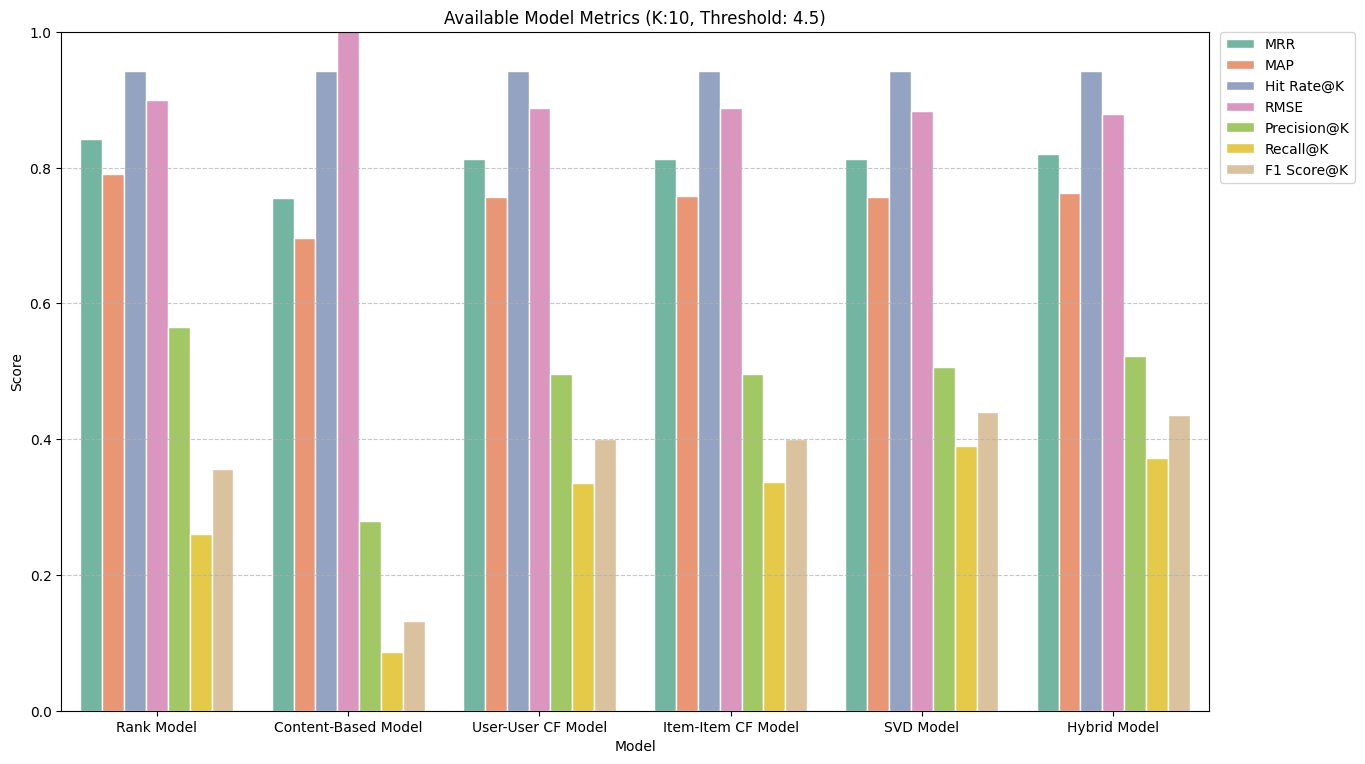

In [ ]:
# Compare whichever model metrics are currently available in the notebook kernel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

if "prepare_and_display_metrics" not in globals():
    import sys
    if "../" not in sys.path:
        sys.path.append("../")
    from src.utils import prepare_and_display_metrics

if "palette_color" not in globals():
    palette_color = "tab10"

if "k" not in globals():
    k = 10

if "threshold" not in globals():
    threshold = 4.5

metrics = {}
algo_names = []

if "model_rank_metric" in globals():
    metrics["Rank Model"] = model_rank_metric[1]
    algo_names.append(getattr(model_rank, "algo_name", "BAvg"))

if "content_based_metric" in globals():
    metrics["Content-Based Model"] = content_based_metric
    algo_names.append("Content-Based")

if "model_uu_opt_metric" in globals():
    metrics["User-User CF Model"] = model_uu_opt_metric[1]
    algo_names.append(getattr(model_uu, "algo_name", "User-User CF"))

if "model_ii_opt_metric" in globals():
    metrics["Item-Item CF Model"] = model_ii_opt_metric[1]
    algo_names.append(getattr(model_ii, "algo_name", "Item-Item CF"))

if "model_svd_opt_metric" in globals():
    metrics["SVD Model"] = model_svd_opt_metric[1]
    algo_names.append(getattr(model_svd, "algo_name", "SVD"))

if "hybrid_metric" in globals():
    metrics["Hybrid Model"] = hybrid_metric[1]
    algo_names.append(getattr(model_hybrid, "algo_name", "Hybrid"))

if not metrics:
    raise ValueError(
        "No model metrics are available yet. Run at least the Content-Based evaluation cell, "
        "or run the model training/evaluation sections before Model Comparison."
    )

prepare_and_display_metrics(metrics, algo_names, "Available Model Metrics")

metrics_df = pd.DataFrame(metrics).T.reset_index()
metrics_long = pd.melt(
    metrics_df, id_vars="index", var_name="Metric", value_name="Score"
)
metrics_long.columns = ["Model", "Metric", "Score"]
metrics_long = metrics_long.dropna(subset=["Score"])

plt.figure(figsize=(14, 8))
sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    palette=palette_color,
    data=metrics_long,
    edgecolor="white",
)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0.0)
plt.title(f"Available Model Metrics (K:{k}, Threshold: {threshold})")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(0, 1)
plt.tight_layout(pad=2.0)
plt.show()


**Observations**:

The dominance of popular items in the recommendations is a common characteristic across these collaborative filtering techniques due to the nature of sparse data and interaction patterns, often leading to inflated ranking metrics and overfitting struggles. This comparison explores how each model balances predictive accuracy, ranking performance, and the challenges posed by sparsity, cold start, and overfitting.

- **RMSE**: The **Hybrid Model** achieves the lowest RMSE (0.879), indicating better predictive accuracy compared to the individual models. The **Rank Model** has the highest RMSE (0.899), reflecting its reliance on **Bayesian Averages** which may not capture individual preferences as effectively.
- **Precision@K**: The **Rank Model** achieves the highest precision (0.565), with the **Hybrid Model** following at 0.522. This indicates that the hybrid approach still improves top-10 recommendation relevance compared to other collaborative filtering methods.
- **Recall@K**: The **SVD Model** demonstrates the highest recall (0.391), indicating a stronger ability to capture relevant items across the dataset. However, the **Hybrid Model** closely follows with a recall of 0.375, showing that it balances between ranking and prediction accuracy.
- **Ranking Metrics**: The **Rank Model** leads in **MRR** (0.842) and **MAP** (0.791), suggesting that it effectively ranks the most popular items. The **Hybrid Model** achieves the second-highest **MRR** (0.819) and **MAP** (0.763), indicating a good balance between the collaborative and rank-based approaches.
- **Hit Rate@K**: All models show a high hit rate of 0.943, demonstrating their effectiveness in including at least one relevant item within the top-K recommendations, regardless of their underlying method.

### Export of Tuned Model

In [ ]:
# Export the tuned SVD model only when the SVD training cells have been run
from pathlib import Path
import pickle

filename = Path("../models/final_model_svd.pkl")

if "model_svd" in globals():
    if "reader" not in globals():
        from surprise.reader import Reader
        reader = Reader(rating_scale=(0, 5))

    if "Dataset" not in globals():
        from surprise.dataset import Dataset

    full_data = Dataset.load_from_df(df[["user_id", "prod_id", "rating"]], reader)
    full_trainset = full_data.build_full_trainset()

    final_model = model_svd.model
    final_model.fit(full_trainset)

    with open(filename, "wb") as f:
        pickle.dump(final_model, f)

    print(f"Parameters: {model_svd.best_params}")
    print(f"Tuned model exported successfully to '{filename}'")
elif filename.exists():
    with open(filename, "rb") as f:
        final_model = pickle.load(f)
    print(
        f"Loaded existing tuned model from '{filename}'. "
        "Run the SVD training cells first if you want to retrain and export it."
    )
else:
    print(
        "Skipping tuned model export because model_svd is not defined. "
        "Run the SVD training/tuning section first."
    )


Parameters: {'n_factors': 11, 'n_epochs': 56, 'lr_all': 0.003, 'reg_all': 0.22, 'random_state': 42}
Tuned model exported successfully to '..\models\final_model_svd.pkl'


In [ ]:
# End the timer at the end of the notebook
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Print the elapsed time in a readable format
print(f"Notebook runtime: {elapsed_time:.2f} seconds")
print(f"Notebook runtime: {(elapsed_time/60):.2f} minutes")

Notebook runtime: 1459.72 seconds
Notebook runtime: 24.33 minutes


## Conclusion and Recommendations

### Conclusion

This project analyzed and compared multiple recommendation models using the Amazon product reviews dataset focused on electronic products. The evaluation revealed that data sparsity, overfitting, and the dominance of popular items significantly impacted the models' performance.

**Key Findings**

- The dataset is highly sparse, containing only **78,798 recorded interactions** out of a possible **10 million** user-product combinations. Additionally, there is a strong **skew towards high ratings**, with **over 82%** of ratings being **4 or higher**. This sparsity and positive rating bias complicate model generalization, reducing the ability to discern finer differences in user preferences and often leading to less diverse recommendations.
- User-product interactions exhibit a **right-skewed distribution** with limited engagement overall, most users have **10 to 50 interactions** and most products are interacted with by **1 to 10 users**, while a **small subset of users and products dominate interactions**, creating notable outliers that can introduce bias in model training.
- **Data sparsity** heavily impacts the models, causing them to favor frequently and highly rated items, which artificially inflates metrics like **Precision@K**, **MRR**, **MAP**, and **Hit Rate@K**. This bias results in overfitting to popular items, failing to capture diverse user preferences and ultimately **lowering Recall@K** by neglecting niche or less common yet relevant items. Despite model tuning, **overfitting** remains an ongoing challenge due to the sparse interactions.
- The **cold start problem** not only affects new users but also new or rarely rated products, such as newly launched electronics, which struggle to gain visibility in recommendations due to the models’ reliance on past interactions.

**Hybrid Model Performance**

- The **Hybrid Model** emerges as the **most balanced approach**, achieving the **lowest RMSE** by combining the strengths of **Rank-Based** and **Model-Based Collaborative Filtering** methods. This integration allows the model to capture high **Precision@K** and **Recall@K**, with an **F1 Score@K** that rivals the best from individual models. 
- Its low RMSE demonstrates a strong balance between fitting the training data and generalizing to new interactions, showcasing its predictive accuracy. This balance makes it a valuable tool for enhancing personalized recommendations in an e-commerce context.
- Beyond securing the **second-highest Recall@K** and **Precision@K**, the hybrid model also maintains strong **ranking metrics** like **MRR** and **MAP**, reflecting its proficiency in identifying and ranking relevant items effectively.
- The hybrid model incorporates the **Rank-Based** approach to effectively address the **cold start problem**, providing meaningful recommendations for new users with limited interaction data
- Despite these strengths, it still **remains influenced by data sparsity** and **biased toward popular items**. Addressing these challenges, such as by incorporating additional data features or exploring more advanced techniques, is crucial to further enhance its generalization and capture a broader range of user preferences.

### Recommendations

Enhancing the recommendation system is anticipated to significantly boost customer engagement, conversion rates, and retention, thereby driving overall business growth. Monitoring key performance metrics is crucial for assessing the impact of these improvements and guiding further optimization efforts.

**Diversifying Recommendation Strategies**

- **Content and Metadata Integration**: Utilize content-based filtering by leveraging machine learning algorithms that analyze product features and metadata (e.g., product descriptions, brands, and categories) to identify similarities between products. This approach enables the recommendation system to suggest items that closely align with a user's interests, even if those items have limited historical interaction data, thereby addressing not only the **cold start problem** but also mitigating issues related to **data sparsity**.
- **Address Data Sparsity**: Implement data augmentation techniques like synthetic interactions and active learning to selectively gather more data for items with sparse interactions. Incorporate implicit feedback signals (e.g., clicks, views, add-to-cart events) to enrich the dataset, thus reducing reliance on popular items and fostering more diverse, accurate recommendations.
- **Continuous Model Evaluation**: Regularly fine-tune model parameters to adapt to changing data patterns, maintaining robustness and improving recommendation quality.
- **Metric Reevaluation**: Introduce metrics such as coverage and novelty to better assess the models' effectiveness in generating diverse recommendations, particularly within sparse datasets. Utilize weighted sampling during training to emphasize underrepresented items and users, ensuring a more balanced model evaluation.

**Strategic Business Actions**

- **A/B Testing for Optimization**: Conduct A/B tests to compare the effectiveness of different recommendation strategies (e.g., personalized vs. trending lists). Use key metrics—**Click-Through Rate (CTR)**, **Conversion Rates**, **Average Order Value (AOV)**, and **Customer Lifetime Value (CLV)**—to identify the most successful approaches and optimize the system continuously.
- **Personalize Marketing Campaigns**: Leverage the hybrid recommendation system to tailor marketing efforts, such as curated email campaigns based on browsing and purchase history. Monitor **CTR** and **Conversion Rates** to gauge engagement and refine future strategies.
- **Target Less Engaged Segments**: Identify and re-engage customer segments with low interaction rates through tailored recommendations, aiming to reduce **Churn Rate** and enhance **CLV**.
- **Diversify Product Promotion**: Adjust the recommendation algorithm to feature lesser-known products alongside top sellers by incorporating a **novelty factor**. Monitor **sales growth** and **AOV** to evaluate the impact of diversifying the product mix in user experiences, assessing both immediate and long-term impacts on customer engagement and satisfaction.


---

# Part 2: popularity.ipynb

This section was copied from the source notebook during merge.


In [ ]:
import os
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**TRAIN + EVALUATE POPULARITY MODELS A/B/C**

Inputs :
*   output/popularity_train_dataset.csv
*   output/interaction_train.csv
*   output/interaction_test.cs
Outputs:
*   output/reports/popularity/


Purpose: train Popularity A/B/C and export metrics, charts, report

In [ ]:
# Input/output files for Popularity A/B/C
# ---------------------------------------------------------
# This section uses the project dataset structure instead of Colab /content paths.
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "input").exists() and (PROJECT_ROOT.parent / "data" / "input").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_INPUT_DIR = PROJECT_ROOT / "data" / "input"
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
POPULARITY_REPORT_DIR = PROJECT_ROOT / "reports" / "popularity"

DATA_INTERIM_DIR.mkdir(parents=True, exist_ok=True)
POPULARITY_REPORT_DIR.mkdir(parents=True, exist_ok=True)

POPULARITY_TRAIN_FILE = DATA_INTERIM_DIR / "popularity_train_dataset.csv"
INTERACTION_TRAIN_FILE = DATA_INPUT_DIR / "interaction_train.csv"
INTERACTION_TEST_FILE = DATA_INPUT_DIR / "interaction_test.csv"

# Optional: if you later have CF/CB/SVD metric CSVs using the same schema,
# put them here and this script will combine them into one comparison report.
EXTERNAL_MODEL_METRIC_FILES = [
    # PROJECT_ROOT / "reports" / "cf" / "model_metrics.csv",
    # PROJECT_ROOT / "reports" / "content_based" / "model_metrics.csv",
    # PROJECT_ROOT / "reports" / "svd" / "model_metrics.csv",
]

REPORT_DIR = str(POPULARITY_REPORT_DIR)
CHART_DIR = str(POPULARITY_REPORT_DIR / "charts")

print("Popularity train file:", POPULARITY_TRAIN_FILE)
print("Interaction train file:", INTERACTION_TRAIN_FILE)
print("Interaction test file:", INTERACTION_TEST_FILE)


In [ ]:
# -------------------------
# Model config
# -------------------------
TOP_K_LIST = [5, 10, 20]
PRIMARY_K = 10

W_VIEW = 1.0
W_CART = 3.0
W_PURCHASE = 5.0

DECAY_LAMBDA = 0.01
POPULARITY_WEIGHT = 0.5
BAYESIAN_WEIGHT = 0.5

RELEVANT_RATING_THRESHOLD = 4.0

# If True, a product already seen by the user in train will not be recommended again.
EXCLUDE_TRAIN_SEEN = True

# If your dataset is too large and memory becomes an issue, set this to an int,
# e.g. 10000. Default None evaluates all users in test.
MAX_EVAL_USERS = None

# To avoid huge files, only sample user-level recommendation output.
SAVE_RECOMMENDATION_SAMPLE = True
RECOMMENDATION_SAMPLE_USERS = 100

# Save per-user metrics for analysis. For very large user counts, set False.
SAVE_USER_METRICS = True

CHUNKSIZE = 100_000

In [ ]:
# ============================================================
# BASIC UTILITIES
# ============================================================

def ensure_input_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Input file not found: {path}")


def ensure_dirs():
    os.makedirs(REPORT_DIR, exist_ok=True)
    os.makedirs(CHART_DIR, exist_ok=True)


def safe_minmax(series):
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    min_v = s.min()
    max_v = s.max()
    if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - min_v) / (max_v - min_v)


def read_csv_required(path, required_cols):
    ensure_input_file(path)
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return df

In [ ]:
# ============================================================
# LOAD / BUILD POPULARITY TRAIN DATA
# ============================================================


def _first_non_null_mode(series):
    modes = series.dropna().mode()
    return modes.iloc[0] if len(modes) else None


def build_popularity_train_dataset(chunksize=CHUNKSIZE):
    """
    Build product-level popularity features from interaction_train.csv.

    Required output columns:
    ProductId, ViewCount, CartCount, PurchaseCount, AvgRating,
    RatingCount, LastTimestamp, LastDate.
    """
    ensure_input_file(INTERACTION_TRAIN_FILE)
    os.makedirs(os.path.dirname(str(POPULARITY_TRAIN_FILE)), exist_ok=True)

    product_stats = {}
    total_rows = 0

    for chunk_index, chunk in enumerate(pd.read_csv(INTERACTION_TRAIN_FILE, chunksize=chunksize, low_memory=False), start=1):
        chunk.columns = chunk.columns.str.strip()

        required_cols = ["ProductId", "Rating"]
        missing = [col for col in required_cols if col not in chunk.columns]
        if missing:
            raise ValueError(f"{INTERACTION_TRAIN_FILE} is missing columns: {missing}")

        chunk["ProductId"] = chunk["ProductId"].astype(str).str.strip()
        chunk["Rating"] = pd.to_numeric(chunk["Rating"], errors="coerce")
        chunk = chunk.dropna(subset=["ProductId", "Rating"])
        chunk = chunk[chunk["ProductId"].str.len() > 0].copy()

        if "Timestamp" in chunk.columns:
            chunk["Timestamp"] = pd.to_numeric(chunk["Timestamp"], errors="coerce")
        else:
            chunk["Timestamp"] = np.nan

        if "Date" in chunk.columns:
            chunk["Date"] = pd.to_datetime(chunk["Date"], errors="coerce")
        else:
            chunk["Date"] = pd.to_datetime(chunk["Timestamp"], unit="s", errors="coerce")

        if "VerifiedPurchase" in chunk.columns:
            chunk["VerifiedPurchase"] = pd.to_numeric(chunk["VerifiedPurchase"], errors="coerce").fillna(0)
        else:
            chunk["VerifiedPurchase"] = 0

        grouped = chunk.groupby("ProductId", sort=False).agg(
            ViewCount=("ProductId", "size"),
            PurchaseCount=("VerifiedPurchase", "sum"),
            RatingSum=("Rating", "sum"),
            RatingCount=("Rating", "count"),
            LastTimestamp=("Timestamp", "max"),
            LastDate=("Date", "max"),
        )

        if "SourceCategory" in chunk.columns:
            categories = chunk.groupby("ProductId")["SourceCategory"].agg(_first_non_null_mode)
        else:
            categories = pd.Series(index=grouped.index, dtype="object")

        for product_id, row in grouped.iterrows():
            stats = product_stats.setdefault(
                product_id,
                {
                    "ViewCount": 0,
                    "PurchaseCount": 0.0,
                    "RatingSum": 0.0,
                    "RatingCount": 0,
                    "LastTimestamp": np.nan,
                    "LastDate": pd.NaT,
                    "SourceCategory": None,
                },
            )
            stats["ViewCount"] += int(row["ViewCount"])
            stats["PurchaseCount"] += float(row["PurchaseCount"])
            stats["RatingSum"] += float(row["RatingSum"])
            stats["RatingCount"] += int(row["RatingCount"])

            if pd.notna(row["LastTimestamp"]) and (pd.isna(stats["LastTimestamp"]) or row["LastTimestamp"] > stats["LastTimestamp"]):
                stats["LastTimestamp"] = float(row["LastTimestamp"])

            if pd.notna(row["LastDate"]) and (pd.isna(stats["LastDate"]) or row["LastDate"] > stats["LastDate"]):
                stats["LastDate"] = row["LastDate"]

            if stats["SourceCategory"] is None and product_id in categories.index and pd.notna(categories.loc[product_id]):
                stats["SourceCategory"] = categories.loc[product_id]

        total_rows += len(chunk)
        print(f"popularity build chunk {chunk_index}: processed {total_rows:,} valid rows", flush=True)

    rows = []
    for product_id, stats in product_stats.items():
        rating_count = stats["RatingCount"]
        rows.append(
            {
                "ProductId": product_id,
                "ViewCount": stats["ViewCount"],
                "CartCount": 0,
                "PurchaseCount": stats["PurchaseCount"],
                "AvgRating": stats["RatingSum"] / rating_count if rating_count else np.nan,
                "RatingCount": rating_count,
                "LastTimestamp": stats["LastTimestamp"],
                "LastDate": stats["LastDate"],
                "SourceCategory": stats["SourceCategory"],
            }
        )

    popularity_df = pd.DataFrame(rows)
    popularity_df.to_csv(POPULARITY_TRAIN_FILE, index=False)
    print(f"Saved popularity train dataset: {POPULARITY_TRAIN_FILE}", flush=True)
    return popularity_df


def load_popularity_train_dataset():
    required_cols = [
        "ProductId",
        "ViewCount",
        "CartCount",
        "PurchaseCount",
        "AvgRating",
        "RatingCount",
        "LastTimestamp",
        "LastDate",
    ]

    if not os.path.exists(POPULARITY_TRAIN_FILE):
        print("popularity_train_dataset.csv not found. Building it from interaction_train.csv...", flush=True)
        build_popularity_train_dataset()

    df = read_csv_required(POPULARITY_TRAIN_FILE, required_cols)

    numeric_cols = [
        "ViewCount",
        "CartCount",
        "PurchaseCount",
        "AvgRating",
        "RatingCount",
        "LastTimestamp",
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["LastDate"] = pd.to_datetime(df["LastDate"], errors="coerce")

    df = df.dropna(
        subset=[
            "ProductId",
            "ViewCount",
            "CartCount",
            "PurchaseCount",
            "AvgRating",
            "RatingCount",
            "LastTimestamp",
            "LastDate",
        ]
    ).copy()

    df = df[df["RatingCount"] > 0].copy()
    df["ProductId"] = df["ProductId"].astype(str).str.strip()
    df = df[df["ProductId"].str.len() > 0].copy()

    print(f"Loaded popularity train products: {len(df):,}", flush=True)
    return df


In [ ]:
# ================
# TRAIN MODELS A
# ================
def train_model_a_popularity_only(product_df):
    """
    MODEL A: POPULARITY ONLY
    Score_A = View + 3*Cart + 5*Purchase
    """
    df = product_df.copy()

    df["Score_A"] = (
        W_VIEW * df["ViewCount"]
        + W_CART * df["CartCount"]
        + W_PURCHASE * df["PurchaseCount"]
    )

    df["PredRating_A"] = df["AvgRating"]

    df = df.sort_values("Score_A", ascending=False).reset_index(drop=True)
    df["Rank_A"] = df.index + 1

    return df

In [ ]:
# ================
# TRAIN MODELS B
# ================
def train_model_b_popularity_time_decay(product_df):
    """
    MODEL B: POPULARITY + TIME DECAY
    Score_B = PopularityScore * DecayFactor
    """
    df = product_df.copy()

    latest_date = df["LastDate"].max()
    df["AgeInDays"] = (latest_date - df["LastDate"]).dt.days.clip(lower=0)

    df["PopularityScore"] = (
        W_VIEW * df["ViewCount"]
        + W_CART * df["CartCount"]
        + W_PURCHASE * df["PurchaseCount"]
    )

    df["DecayFactor"] = np.exp(-DECAY_LAMBDA * df["AgeInDays"])
    df["Score_B"] = df["PopularityScore"] * df["DecayFactor"]
    df["PredRating_B"] = df["AvgRating"]

    df = df.sort_values("Score_B", ascending=False).reset_index(drop=True)
    df["Rank_B"] = df.index + 1

    return df

In [ ]:
# ================
# TRAIN MODELS C
# ================
def train_model_c_rank_based_bayesian(product_df):
    """
    MODEL C: RANK-BASED POPULARITY + BAYESIAN AVERAGE
    Score_C = 0.5*PopularityDecayNorm + 0.5*BayesianNorm
    """
    df = product_df.copy()

    latest_date = df["LastDate"].max()
    df["AgeInDays"] = (latest_date - df["LastDate"]).dt.days.clip(lower=0)

    df["PopularityScore"] = (
        W_VIEW * df["ViewCount"]
        + W_CART * df["CartCount"]
        + W_PURCHASE * df["PurchaseCount"]
    )

    df["DecayFactor"] = np.exp(-DECAY_LAMBDA * df["AgeInDays"])
    df["PopularityDecayScore"] = df["PopularityScore"] * df["DecayFactor"]

    global_avg_rating = df["AvgRating"].mean()
    k = df["RatingCount"].mean()

    df["BayesianAvg"] = (
        global_avg_rating * k
        + df["AvgRating"] * df["RatingCount"]
    ) / (k + df["RatingCount"])

    df["PopularityDecayNorm"] = safe_minmax(df["PopularityDecayScore"])
    df["BayesianNorm"] = safe_minmax(df["BayesianAvg"])

    df["Score_C"] = (
        POPULARITY_WEIGHT * df["PopularityDecayNorm"]
        + BAYESIAN_WEIGHT * df["BayesianNorm"]
    )

    df["PredRating_C"] = df["BayesianAvg"]

    df = df.sort_values("Score_C", ascending=False).reset_index(drop=True)
    df["Rank_C"] = df.index + 1

    return df

In [ ]:
# ============================================================
# PREPARE GLOBAL RANKED LISTS
# ============================================================

def build_ranked_lists(model_a_df, model_b_df, model_c_df):
    ranked_lists = {
        "Popularity_A_Only": model_a_df["ProductId"].tolist(),
        "Popularity_B_TimeDecay": model_b_df["ProductId"].tolist(),
        "Popularity_C_Bayesian": model_c_df["ProductId"].tolist(),
    }
    return ranked_lists

In [ ]:
# ============================================================
# LOAD TRAIN SEEN + TEST ACTUALS
# ============================================================

def load_train_seen_items():
    """
    Build user -> set(ProductId) from interaction_train.csv.
    Used to avoid recommending items already seen in train.
    """
    if not EXCLUDE_TRAIN_SEEN:
        return {}

    ensure_input_file(INTERACTION_TRAIN_FILE)
    seen = defaultdict(set)
    total_rows = 0

    usecols = ["UserId", "ProductId"]

    for i, chunk in enumerate(pd.read_csv(INTERACTION_TRAIN_FILE, usecols=usecols, chunksize=CHUNKSIZE, low_memory=False)):
        chunk["UserId"] = chunk["UserId"].astype(str).str.strip()
        chunk["ProductId"] = chunk["ProductId"].astype(str).str.strip()
        chunk = chunk.dropna(subset=["UserId", "ProductId"])

        for user_id, product_id in zip(chunk["UserId"], chunk["ProductId"]):
            if user_id and product_id:
                seen[user_id].add(product_id)

        total_rows += len(chunk)
        print(f"train seen chunk {i + 1}: processed {total_rows:,} rows", flush=True)

    print(f"Loaded train seen users: {len(seen):,}", flush=True)
    return seen


def load_test_actual_items():
    """
    Build user -> set(relevant ProductId) from interaction_test.csv.
    Relevant item = IsRelevant == 1 if the column exists, otherwise Rating >= threshold.
    Also return all test users.
    """
    ensure_input_file(INTERACTION_TEST_FILE)

    actual = defaultdict(set)
    test_users = set()
    total_rows = 0
    relevant_rows = 0

    for i, chunk in enumerate(pd.read_csv(INTERACTION_TEST_FILE, chunksize=CHUNKSIZE, low_memory=False)):
        chunk.columns = chunk.columns.str.strip()

        required_cols = ["UserId", "ProductId", "Rating"]
        missing = [c for c in required_cols if c not in chunk.columns]
        if missing:
            raise ValueError(f"{INTERACTION_TEST_FILE} is missing columns: {missing}")

        chunk["UserId"] = chunk["UserId"].astype(str).str.strip()
        chunk["ProductId"] = chunk["ProductId"].astype(str).str.strip()
        chunk["Rating"] = pd.to_numeric(chunk["Rating"], errors="coerce")
        chunk = chunk.dropna(subset=["UserId", "ProductId", "Rating"])

        if "IsRelevant" in chunk.columns:
            chunk["IsRelevant"] = pd.to_numeric(chunk["IsRelevant"], errors="coerce").fillna(0).astype(int)
        else:
            chunk["IsRelevant"] = (chunk["Rating"] >= RELEVANT_RATING_THRESHOLD).astype(int)

        for user_id in chunk["UserId"].unique():
            test_users.add(user_id)

        rel_chunk = chunk[chunk["IsRelevant"] == 1]
        for user_id, product_id in zip(rel_chunk["UserId"], rel_chunk["ProductId"]):
            if user_id and product_id:
                actual[user_id].add(product_id)

        total_rows += len(chunk)
        relevant_rows += len(rel_chunk)
        print(
            f"test actual chunk {i + 1}: rows {total_rows:,} | relevant {relevant_rows:,}",
            flush=True,
        )

    # Evaluate only users with at least one relevant item in test.
    actual = {u: items for u, items in actual.items() if len(items) > 0}

    if MAX_EVAL_USERS is not None:
        selected_users = list(actual.keys())[:MAX_EVAL_USERS]
        actual = {u: actual[u] for u in selected_users}

    print(f"Loaded test users with relevant items: {len(actual):,}", flush=True)
    return actual, test_users

In [ ]:
# ============================================================
# RECOMMENDATION + METRICS
# ============================================================

def recommend_for_user(global_ranked_products, seen_items, k):
    recs = []
    seen_items = seen_items or set()

    for product_id in global_ranked_products:
        if EXCLUDE_TRAIN_SEEN and product_id in seen_items:
            continue
        recs.append(product_id)
        if len(recs) >= k:
            break

    return recs


def precision_at_k(recs, actual, k):
    if k == 0:
        return 0.0
    return len(set(recs[:k]) & actual) / k


def recall_at_k(recs, actual, k):
    if len(actual) == 0:
        return 0.0
    return len(set(recs[:k]) & actual) / len(actual)


def f1_at_k(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def hit_rate_at_k(recs, actual, k):
    return 1.0 if len(set(recs[:k]) & actual) > 0 else 0.0


def average_precision_at_k(recs, actual, k):
    if len(actual) == 0:
        return 0.0

    score = 0.0
    hits = 0

    for idx, product_id in enumerate(recs[:k], start=1):
        if product_id in actual:
            hits += 1
            score += hits / idx

    if hits == 0:
        return 0.0

    return score / min(len(actual), k)


def reciprocal_rank_at_k(recs, actual, k):
    for idx, product_id in enumerate(recs[:k], start=1):
        if product_id in actual:
            return 1.0 / idx
    return 0.0


def ndcg_at_k(recs, actual, k):
    dcg = 0.0
    for idx, product_id in enumerate(recs[:k], start=1):
        rel = 1.0 if product_id in actual else 0.0
        if rel > 0:
            dcg += rel / math.log2(idx + 1)

    ideal_hits = min(len(actual), k)
    if ideal_hits == 0:
        return 0.0

    idcg = sum(1.0 / math.log2(idx + 1) for idx in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_ranking_model(model_name, ranked_products, actual_by_user, train_seen_by_user, k_list):
    rows = []
    user_metric_rows = []
    sample_recommendations = []

    max_k = max(k_list)
    users = list(actual_by_user.keys())

    for user_index, user_id in enumerate(users, start=1):
        actual = actual_by_user[user_id]
        seen = train_seen_by_user.get(user_id, set()) if EXCLUDE_TRAIN_SEEN else set()
        recs = recommend_for_user(ranked_products, seen, max_k)

        if SAVE_RECOMMENDATION_SAMPLE and user_index <= RECOMMENDATION_SAMPLE_USERS:
            sample_recommendations.append({
                "Model": model_name,
                "UserId": user_id,
                "RecommendedProducts": "|".join(recs),
                "ActualRelevantProducts": "|".join(list(actual)[:max_k]),
            })

        for k in k_list:
            p = precision_at_k(recs, actual, k)
            r = recall_at_k(recs, actual, k)
            f1 = f1_at_k(p, r)
            hr = hit_rate_at_k(recs, actual, k)
            ap = average_precision_at_k(recs, actual, k)
            rr = reciprocal_rank_at_k(recs, actual, k)
            ndcg = ndcg_at_k(recs, actual, k)

            user_metric_rows.append({
                "Model": model_name,
                "UserId": user_id,
                "K": k,
                "Precision@K": p,
                "Recall@K": r,
                "F1@K": f1,
                "HitRate@K": hr,
                "AP@K": ap,
                "RR@K": rr,
                "NDCG@K": ndcg,
                "ActualRelevantCount": len(actual),
            })

        if user_index % 5000 == 0:
            print(f"{model_name}: evaluated {user_index:,}/{len(users):,} users", flush=True)

    user_metrics_df = pd.DataFrame(user_metric_rows)

    for k in k_list:
        k_df = user_metrics_df[user_metrics_df["K"] == k]
        recommended_catalog = set(ranked_products[:k])

        rows.append({
            "Model": model_name,
            "K": k,
            "EvaluatedUsers": len(users),
            "Precision@K": k_df["Precision@K"].mean(),
            "Recall@K": k_df["Recall@K"].mean(),
            "F1@K": k_df["F1@K"].mean(),
            "HitRate@K": k_df["HitRate@K"].mean(),
            "MAP@K": k_df["AP@K"].mean(),
            "MRR@K": k_df["RR@K"].mean(),
            "NDCG@K": k_df["NDCG@K"].mean(),
            "CatalogCoverage@K": len(recommended_catalog) / len(ranked_products) if len(ranked_products) > 0 else 0,
        })

    summary_df = pd.DataFrame(rows)
    sample_df = pd.DataFrame(sample_recommendations)

    return summary_df, user_metrics_df, sample_df


In [ ]:
# ============================================================
# RATING PREDICTION METRICS: RMSE / MAE
# ============================================================

def build_prediction_maps(model_a_df, model_b_df, model_c_df):
    return {
        "Popularity_A_Only": model_a_df.set_index("ProductId")["PredRating_A"].to_dict(),
        "Popularity_B_TimeDecay": model_b_df.set_index("ProductId")["PredRating_B"].to_dict(),
        "Popularity_C_Bayesian": model_c_df.set_index("ProductId")["PredRating_C"].to_dict(),
    }


def evaluate_rating_prediction(prediction_maps):
    ensure_input_file(INTERACTION_TEST_FILE)

    stats = {
        model_name: {
            "count": 0,
            "squared_error_sum": 0.0,
            "absolute_error_sum": 0.0,
        }
        for model_name in prediction_maps.keys()
    }

    for i, chunk in enumerate(pd.read_csv(INTERACTION_TEST_FILE, chunksize=CHUNKSIZE, low_memory=False)):
        chunk.columns = chunk.columns.str.strip()
        chunk["ProductId"] = chunk["ProductId"].astype(str).str.strip()
        chunk["Rating"] = pd.to_numeric(chunk["Rating"], errors="coerce")
        chunk = chunk.dropna(subset=["ProductId", "Rating"])

        for model_name, pred_map in prediction_maps.items():
            preds = chunk["ProductId"].map(pred_map)
            valid_mask = preds.notna()

            if valid_mask.sum() == 0:
                continue

            y_true = chunk.loc[valid_mask, "Rating"].astype(float)
            y_pred = preds.loc[valid_mask].astype(float)

            errors = y_true - y_pred
            stats[model_name]["count"] += len(errors)
            stats[model_name]["squared_error_sum"] += float(np.sum(errors ** 2))
            stats[model_name]["absolute_error_sum"] += float(np.sum(np.abs(errors)))

        print(f"rating prediction chunk {i + 1}: processed {len(chunk):,} rows", flush=True)

    rows = []
    for model_name, s in stats.items():
        if s["count"] == 0:
            rmse = np.nan
            mae = np.nan
        else:
            rmse = math.sqrt(s["squared_error_sum"] / s["count"])
            mae = s["absolute_error_sum"] / s["count"]

        rows.append({
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "RatingEvalRows": s["count"],
        })

    return pd.DataFrame(rows)

In [ ]:

# ============================================================
# TOP PRODUCTS + RANK COMPARISON
# ============================================================

def build_rank_comparison(model_a_df, model_b_df, model_c_df):
    base_cols = ["ProductId"]
    optional_cols = ["Title", "MainCategory", "SourceCategory", "AvgRating", "RatingCount"]

    rank_a = model_a_df[base_cols + ["Rank_A", "Score_A"]].copy()
    rank_b = model_b_df[base_cols + ["Rank_B", "Score_B"]].copy()

    c_cols = base_cols + [
        "Rank_C",
        "Score_C",
        "BayesianAvg",
        "PopularityDecayScore",
        "PopularityDecayNorm",
        "BayesianNorm",
    ]

    for col in optional_cols:
        if col in model_c_df.columns:
            c_cols.append(col)

    rank_c = model_c_df[c_cols].copy()

    compare = (
        rank_a
        .merge(rank_b, on="ProductId", how="inner")
        .merge(rank_c, on="ProductId", how="inner")
    )

    compare["Change_A_to_C"] = compare["Rank_A"] - compare["Rank_C"]
    compare["Change_B_to_C"] = compare["Rank_B"] - compare["Rank_C"]

    compare = compare.sort_values("Rank_C", ascending=True).reset_index(drop=True)
    return compare


def build_top_products(model_df, model_name, score_col, rank_col, top_n=20):
    cols = ["ProductId", rank_col, score_col, "AvgRating", "RatingCount"]
    for col in ["Title", "MainCategory", "SourceCategory", "Price"]:
        if col in model_df.columns:
            cols.append(col)

    out = model_df.head(top_n)[cols].copy()
    out.insert(0, "Model", model_name)
    return out

In [ ]:
# ============================================================
# CHARTS
# ============================================================

SAVE_GROUPED_DASHBOARD = True
SAVE_SEPARATE_CHARTS = False


def save_grouped_ranking_metrics_chart(metrics_df, k=PRIMARY_K):
    """
    One grouped chart for ranking metrics:
    Precision, Recall, F1, HitRate, MAP, MRR, NDCG.
    """

    metrics = [
        "Precision@K",
        "Recall@K",
        "F1@K",
        "HitRate@K",
        "MAP@K",
        "MRR@K",
        "NDCG@K"
    ]

    df = metrics_df[metrics_df["K"] == k].copy()

    if len(df) == 0:
        print("No data for grouped ranking metrics chart.")
        return

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(16, 8))

    for idx, (_, row) in enumerate(df.iterrows()):
        values = [row[m] for m in metrics]
        plt.bar(
            x + (idx - 1) * width,
            values,
            width,
            label=row["Model"]
        )

    plt.xticks(x, metrics, rotation=30, ha="right")
    plt.ylabel("Score")
    plt.title(f"Grouped Ranking Metrics Comparison @ {k}")
    plt.legend()
    plt.tight_layout()

    path = f"{CHART_DIR}/grouped_ranking_metrics_k{k}.png"
    plt.savefig(path, dpi=150)
    plt.close()

    print("Saved chart:", path, flush=True)


def save_grouped_error_chart(rating_df):
    """
    One grouped chart for RMSE and MAE.
    """

    if len(rating_df) == 0:
        print("No data for grouped error chart.")
        return

    x = np.arange(len(rating_df))
    width = 0.35

    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width / 2,
        rating_df["RMSE"],
        width,
        label="RMSE"
    )

    plt.bar(
        x + width / 2,
        rating_df["MAE"],
        width,
        label="MAE"
    )

    plt.xticks(
        x,
        rating_df["Model"],
        rotation=20,
        ha="right"
    )

    plt.ylabel("Error")
    plt.title("Grouped Rating Prediction Error Comparison")
    plt.legend()
    plt.tight_layout()

    path = f"{CHART_DIR}/grouped_error_metrics.png"
    plt.savefig(path, dpi=150)
    plt.close()

    print("Saved chart:", path, flush=True)


def save_grouped_top_rank_score_chart(
    model_a_df,
    model_b_df,
    model_c_df,
    top_n=10
):
    """
    Compare normalized top-rank scores of A/B/C by rank position.
    This avoids the problem that Score_A, Score_B, Score_C have different scales.
    """

    a = model_a_df.head(top_n)[["Rank_A", "Score_A"]].copy()
    b = model_b_df.head(top_n)[["Rank_B", "Score_B"]].copy()
    c = model_c_df.head(top_n)[["Rank_C", "Score_C"]].copy()

    a["Rank"] = range(1, len(a) + 1)
    b["Rank"] = range(1, len(b) + 1)
    c["Rank"] = range(1, len(c) + 1)

    a["NormalizedScore"] = safe_minmax(a["Score_A"])
    b["NormalizedScore"] = safe_minmax(b["Score_B"])
    c["NormalizedScore"] = safe_minmax(c["Score_C"])

    plt.figure(figsize=(12, 6))

    plt.plot(
        a["Rank"],
        a["NormalizedScore"],
        marker="o",
        label="Model A"
    )

    plt.plot(
        b["Rank"],
        b["NormalizedScore"],
        marker="o",
        label="Model B"
    )

    plt.plot(
        c["Rank"],
        c["NormalizedScore"],
        marker="o",
        label="Model C"
    )

    plt.xlabel("Rank position")
    plt.ylabel("Normalized score")
    plt.title(f"Top-{top_n} Normalized Score Trend by Rank")
    plt.xticks(range(1, top_n + 1))
    plt.legend()
    plt.tight_layout()

    path = f"{CHART_DIR}/grouped_top_rank_scores.png"
    plt.savefig(path, dpi=150)
    plt.close()

    print("Saved chart:", path, flush=True)


def save_grouped_topk_overlap_chart(
    model_a_df,
    model_b_df,
    model_c_df,
    k=PRIMARY_K
):
    """
    One grouped chart showing overlap rate between model top-K lists.
    """

    top_a = set(model_a_df.head(k)["ProductId"])
    top_b = set(model_b_df.head(k)["ProductId"])
    top_c = set(model_c_df.head(k)["ProductId"])

    labels = [
        "A vs B",
        "A vs C",
        "B vs C"
    ]

    values = [
        len(top_a & top_b) / k,
        len(top_a & top_c) / k,
        len(top_b & top_c) / k
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.ylabel("Overlap rate")
    plt.title(f"Top-{k} Overlap Rate Between Models")
    plt.tight_layout()

    path = f"{CHART_DIR}/grouped_topk_overlap_k{k}.png"
    plt.savefig(path, dpi=150)
    plt.close()

    print("Saved chart:", path, flush=True)


def save_dashboard_chart(
    metrics_df,
    rating_df,
    model_a_df,
    model_b_df,
    model_c_df,
    k=PRIMARY_K
):
    """
    One dashboard image containing:
    1. Ranking metrics
    2. RMSE/MAE
    3. Top-K overlap
    4. Top-rank normalized score trend
    """

    metrics = [
        "Precision@K",
        "Recall@K",
        "F1@K",
        "HitRate@K",
        "MAP@K",
        "MRR@K",
        "NDCG@K"
    ]

    ranking_df = metrics_df[metrics_df["K"] == k].copy()

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    # -------------------------
    # Chart 1: Ranking metrics
    # -------------------------

    ax1 = axes[0, 0]

    x = np.arange(len(metrics))
    width = 0.25

    for idx, (_, row) in enumerate(ranking_df.iterrows()):
        values = [row[m] for m in metrics]
        ax1.bar(
            x + (idx - 1) * width,
            values,
            width,
            label=row["Model"]
        )

    ax1.set_title(f"Ranking Metrics @ {k}")
    ax1.set_ylabel("Score")
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics, rotation=30, ha="right")
    ax1.legend()

    # -------------------------
    # Chart 2: RMSE / MAE
    # -------------------------

    ax2 = axes[0, 1]

    error_x = np.arange(len(rating_df))
    error_width = 0.35

    ax2.bar(
        error_x - error_width / 2,
        rating_df["RMSE"],
        error_width,
        label="RMSE"
    )

    ax2.bar(
        error_x + error_width / 2,
        rating_df["MAE"],
        error_width,
        label="MAE"
    )

    ax2.set_title("Rating Prediction Error")
    ax2.set_ylabel("Error")
    ax2.set_xticks(error_x)
    ax2.set_xticklabels(
        rating_df["Model"],
        rotation=20,
        ha="right"
    )
    ax2.legend()

    # -------------------------
    # Chart 3: Top-K overlap
    # -------------------------

    ax3 = axes[1, 0]

    top_a = set(model_a_df.head(k)["ProductId"])
    top_b = set(model_b_df.head(k)["ProductId"])
    top_c = set(model_c_df.head(k)["ProductId"])

    overlap_labels = [
        "A vs B",
        "A vs C",
        "B vs C"
    ]

    overlap_values = [
        len(top_a & top_b) / k,
        len(top_a & top_c) / k,
        len(top_b & top_c) / k
    ]

    ax3.bar(overlap_labels, overlap_values)
    ax3.set_ylim(0, 1)
    ax3.set_title(f"Top-{k} Overlap Rate")
    ax3.set_ylabel("Overlap rate")

    # -------------------------
    # Chart 4: Top-rank normalized scores
    # -------------------------

    ax4 = axes[1, 1]

    top_n = 10

    a = model_a_df.head(top_n).copy()
    b = model_b_df.head(top_n).copy()
    c = model_c_df.head(top_n).copy()

    a["Rank"] = range(1, len(a) + 1)
    b["Rank"] = range(1, len(b) + 1)
    c["Rank"] = range(1, len(c) + 1)

    a["NormalizedScore"] = safe_minmax(a["Score_A"])
    b["NormalizedScore"] = safe_minmax(b["Score_B"])
    c["NormalizedScore"] = safe_minmax(c["Score_C"])

    ax4.plot(
        a["Rank"],
        a["NormalizedScore"],
        marker="o",
        label="Model A"
    )

    ax4.plot(
        b["Rank"],
        b["NormalizedScore"],
        marker="o",
        label="Model B"
    )

    ax4.plot(
        c["Rank"],
        c["NormalizedScore"],
        marker="o",
        label="Model C"
    )

    ax4.set_title("Top-10 Normalized Score Trend")
    ax4.set_xlabel("Rank position")
    ax4.set_ylabel("Normalized score")
    ax4.set_xticks(range(1, top_n + 1))
    ax4.legend()

    plt.suptitle(
        "Popularity Models Evaluation Dashboard",
        fontsize=16
    )

    plt.tight_layout()

    path = f"{CHART_DIR}/dashboard_popularity_summary.png"
    plt.savefig(path, dpi=150)
    plt.close()

    print("Saved dashboard:", path, flush=True)


def save_charts(
    metrics_df,
    rating_df,
    model_a_df,
    model_b_df,
    model_c_df
):
    """
    Main chart function.
    This version groups charts instead of saving many separate images.
    """

    if SAVE_GROUPED_DASHBOARD:
        save_dashboard_chart(
            metrics_df,
            rating_df,
            model_a_df,
            model_b_df,
            model_c_df,
            PRIMARY_K
        )

    save_grouped_ranking_metrics_chart(
        metrics_df,
        PRIMARY_K
    )

    save_grouped_error_chart(
        rating_df
    )

    save_grouped_top_rank_score_chart(
        model_a_df,
        model_b_df,
        model_c_df,
        top_n=10
    )

    save_grouped_topk_overlap_chart(
        model_a_df,
        model_b_df,
        model_c_df,
        PRIMARY_K
    )

In [ ]:
# ============================================================
# STANDARD COMPARISON WITH CF / CB / SVD
# ============================================================

def load_external_model_metrics():
    frames = []
    for path in EXTERNAL_MODEL_METRIC_FILES:
        if os.path.exists(path):
            df = pd.read_csv(path)
            frames.append(df)
            print(f"Loaded external metrics: {path}", flush=True)
        else:
            print(f"External metrics not found, skipped: {path}", flush=True)

    if frames:
        return pd.concat(frames, ignore_index=True)

    return pd.DataFrame()


def create_external_metrics_template():
    template_cols = [
        "Model",
        "K",
        "EvaluatedUsers",
        "Precision@K",
        "Recall@K",
        "F1@K",
        "HitRate@K",
        "MAP@K",
        "MRR@K",
        "NDCG@K",
        "CatalogCoverage@K",
        "RMSE",
        "MAE",
        "RatingEvalRows",
    ]

    examples = pd.DataFrame([
        {
            "Model": "CF",
            "K": PRIMARY_K,
            "EvaluatedUsers": None,
            "Precision@K": None,
            "Recall@K": None,
            "F1@K": None,
            "HitRate@K": None,
            "MAP@K": None,
            "MRR@K": None,
            "NDCG@K": None,
            "CatalogCoverage@K": None,
            "RMSE": None,
            "MAE": None,
            "RatingEvalRows": None,
        },
        {
            "Model": "Content_Based",
            "K": PRIMARY_K,
            "EvaluatedUsers": None,
            "Precision@K": None,
            "Recall@K": None,
            "F1@K": None,
            "HitRate@K": None,
            "MAP@K": None,
            "MRR@K": None,
            "NDCG@K": None,
            "CatalogCoverage@K": None,
            "RMSE": None,
            "MAE": None,
            "RatingEvalRows": None,
        },
        {
            "Model": "SVD",
            "K": PRIMARY_K,
            "EvaluatedUsers": None,
            "Precision@K": None,
            "Recall@K": None,
            "F1@K": None,
            "HitRate@K": None,
            "MAP@K": None,
            "MRR@K": None,
            "NDCG@K": None,
            "CatalogCoverage@K": None,
            "RMSE": None,
            "MAE": None,
            "RatingEvalRows": None,
        },
    ], columns=template_cols)

    path = f"{REPORT_DIR}/external_model_metrics_template.csv"
    examples.to_csv(path, index=False)
    print("Saved external metrics template:", path, flush=True)

In [ ]:
# ============================================================
# REPORT
# ============================================================

def write_markdown_report(metrics_df, rating_df, combined_df, rank_compare_df):
    primary_metrics = metrics_df[metrics_df["K"] == PRIMARY_K].copy()
    primary_combined = combined_df[combined_df["K"] == PRIMARY_K].copy() if "K" in combined_df.columns else combined_df

    best_map = primary_metrics.sort_values("MAP@K", ascending=False).head(1)
    best_rmse = rating_df.sort_values("RMSE", ascending=True).head(1)

    lines = []
    lines.append("# Popularity Model Training Report")
    lines.append("")
    lines.append("## Models")
    lines.append("")
    lines.append("- Model A: Popularity Only, `Score = View + 3*Cart + 5*Purchase`.")
    lines.append("- Model B: Popularity + Time Decay, `Score = PopularityScore * DecayFactor`.")
    lines.append("- Model C: Rank-Based Popularity + Bayesian Average, `Score = 0.5*PopularityDecayNorm + 0.5*BayesianNorm`.")
    lines.append("")
    lines.append("## Ranking metrics")
    lines.append("")
    lines.append(primary_metrics.to_markdown(index=False))
    lines.append("")
    lines.append("## Rating prediction metrics")
    lines.append("")
    lines.append(rating_df.to_markdown(index=False))
    lines.append("")

    if len(best_map) > 0:
        row = best_map.iloc[0]
        lines.append(f"Best MAP@{PRIMARY_K}: **{row['Model']}** = {row['MAP@K']:.6f}.")
    if len(best_rmse) > 0:
        row = best_rmse.iloc[0]
        lines.append(f"Best RMSE: **{row['Model']}** = {row['RMSE']:.6f}.")

    lines.append("")
    lines.append("## Files generated")
    lines.append("")
    lines.append("- `model_metrics_popularity.csv`: ranking + rating metrics for Popularity A/B/C.")
    lines.append("- `model_metrics_all_models.csv`: popularity metrics plus optional CF/CB/SVD metrics if provided.")
    lines.append("- `ranking_comparison_popularity.csv`: rank movement across A/B/C.")
    lines.append("- `top_products_all_popularity_models.csv`: top ranked products for each Popularity model.")
    lines.append("- `charts/`: comparison charts for report/presentation.")
    lines.append("")
    lines.append("## Notes for team comparison")
    lines.append("")
    lines.append("CF, Content-Based, and SVD should export metrics using the same columns as `external_model_metrics_template.csv`. Then add their metric file paths to `EXTERNAL_MODEL_METRIC_FILES` and rerun this script to generate a combined comparison report.")

    path = f"{REPORT_DIR}/popularity_training_report.md"
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print("Saved markdown report:", path, flush=True)


In [ ]:
# ============================================================
# MAIN
# ============================================================

def main():
    # Paths are configured in the input/output cell above.
    # Do not overwrite them with Colab /content paths here.
    ensure_dirs()

    print("===== LOAD DATA =====", flush=True)
    product_df = load_popularity_train_dataset()

    print("\n===== TRAIN MODELS =====", flush=True)
    model_a_df = train_model_a_popularity_only(product_df)
    model_b_df = train_model_b_popularity_time_decay(product_df)
    model_c_df = train_model_c_rank_based_bayesian(product_df)

    print("Model A top 5:", model_a_df.head(5)["ProductId"].tolist(), flush=True)
    print("Model B top 5:", model_b_df.head(5)["ProductId"].tolist(), flush=True)
    print("Model C top 5:", model_c_df.head(5)["ProductId"].tolist(), flush=True)

    print("\n===== LOAD EVALUATION DATA =====", flush=True)
    train_seen_by_user = load_train_seen_items()
    actual_by_user, _ = load_test_actual_items()

    if len(actual_by_user) == 0:
        raise ValueError("No users with relevant items found in interaction_test.csv. Check IsRelevant or Rating threshold.")

    ranked_lists = build_ranked_lists(model_a_df, model_b_df, model_c_df)

    print("\n===== EVALUATE RANKING METRICS =====", flush=True)
    metric_frames = []
    user_metric_frames = []
    sample_frames = []

    for model_name, ranked_products in ranked_lists.items():
        summary_df, user_metrics_df, sample_df = evaluate_ranking_model(
            model_name,
            ranked_products,
            actual_by_user,
            train_seen_by_user,
            TOP_K_LIST,
        )
        metric_frames.append(summary_df)
        if SAVE_USER_METRICS:
            user_metric_frames.append(user_metrics_df)
        if SAVE_RECOMMENDATION_SAMPLE:
            sample_frames.append(sample_df)

    ranking_metrics_df = pd.concat(metric_frames, ignore_index=True)

    print("\n===== EVALUATE RMSE / MAE =====", flush=True)
    prediction_maps = build_prediction_maps(model_a_df, model_b_df, model_c_df)
    rating_metrics_df = evaluate_rating_prediction(prediction_maps)

    metrics_df = ranking_metrics_df.merge(rating_metrics_df, on="Model", how="left")

    print("\n===== BUILD ANALYSIS OUTPUTS =====", flush=True)
    rank_compare_df = build_rank_comparison(model_a_df, model_b_df, model_c_df)

    top_products_df = pd.concat([
        build_top_products(model_a_df, "Popularity_A_Only", "Score_A", "Rank_A"),
        build_top_products(model_b_df, "Popularity_B_TimeDecay", "Score_B", "Rank_B"),
        build_top_products(model_c_df, "Popularity_C_Bayesian", "Score_C", "Rank_C"),
    ], ignore_index=True)

    external_df = load_external_model_metrics()
    if len(external_df) > 0:
        combined_df = pd.concat([metrics_df, external_df], ignore_index=True, sort=False)
    else:
        combined_df = metrics_df.copy()

    create_external_metrics_template()

    print("\n===== SAVE FILES =====", flush=True)
    model_a_df.to_csv(f"{REPORT_DIR}/model_a_popularity_only_result.csv", index=False)
    model_b_df.to_csv(f"{REPORT_DIR}/model_b_popularity_time_decay_result.csv", index=False)
    model_c_df.to_csv(f"{REPORT_DIR}/model_c_bayesian_rank_based_result.csv", index=False)

    metrics_df.to_csv(f"{REPORT_DIR}/model_metrics_popularity.csv", index=False)
    combined_df.to_csv(f"{REPORT_DIR}/model_metrics_all_models.csv", index=False)
    rank_compare_df.to_csv(f"{REPORT_DIR}/ranking_comparison_popularity.csv", index=False)
    top_products_df.to_csv(f"{REPORT_DIR}/top_products_all_popularity_models.csv", index=False)

    if SAVE_USER_METRICS and user_metric_frames:
        user_metrics_all = pd.concat(user_metric_frames, ignore_index=True)
        user_metrics_all.to_csv(f"{REPORT_DIR}/user_metrics_popularity.csv", index=False)

    if SAVE_RECOMMENDATION_SAMPLE and sample_frames:
        samples_all = pd.concat(sample_frames, ignore_index=True)
        samples_all.to_csv(f"{REPORT_DIR}/recommendation_samples_popularity.csv", index=False)

    print("\n===== SAVE CHARTS =====", flush=True)
    save_charts(metrics_df, rating_metrics_df, model_a_df, model_b_df, model_c_df)

    write_markdown_report(metrics_df, rating_metrics_df, combined_df, rank_compare_df)

    print("\n===== DONE =====", flush=True)
    print("Main metrics file:", f"{REPORT_DIR}/model_metrics_popularity.csv", flush=True)
    print("Combined metrics file:", f"{REPORT_DIR}/model_metrics_all_models.csv", flush=True)
    print("Report:", f"{REPORT_DIR}/popularity_training_report.md", flush=True)


if __name__ == "__main__":
    main()

===== LOAD DATA =====
Loaded popularity train products: 1,366,449

===== TRAIN MODELS =====
Model A top 5: ['B01LSUQSB0', 'B0BVGHXZJ1', 'B0BYBCFHTB', 'B0BS71PXPX', 'B0C777X1L4']
Model B top 5: ['B01LSUQSB0', 'B0BVGHXZJ1', 'B0BYBCFHTB', 'B0BS71PXPX', 'B0C777X1L4']
Model C top 5: ['B01LSUQSB0', 'B0BVGHXZJ1', 'B0C777X1L4', 'B0B6G84457', 'B0B3DB5HTC']

===== LOAD EVALUATION DATA =====
train seen chunk 1: processed 100,000 rows
train seen chunk 2: processed 200,000 rows
train seen chunk 3: processed 300,000 rows
train seen chunk 4: processed 400,000 rows
train seen chunk 5: processed 500,000 rows
train seen chunk 6: processed 600,000 rows
train seen chunk 7: processed 700,000 rows
train seen chunk 8: processed 800,000 rows
train seen chunk 9: processed 900,000 rows
train seen chunk 10: processed 1,000,000 rows
train seen chunk 11: processed 1,100,000 rows
train seen chunk 12: processed 1,200,000 rows
train seen chunk 13: processed 1,300,000 rows
train seen chunk 14: processed 1,400,000 rows